# Dinámica y regímenes de mercado en activos a la Teoría de precios de arbitraje (TPA) 

The arbitrage pricing theory (APT) is a multi-factor asset pricing model. It's based on the idea that an asset's returns can be predicted using the linear relationship between the asset’s expected return and several macroeconomic variables that capture systematic risk. It's a useful tool for analyzing portfolios from a *value investing* perspective to identify securities that may be temporarily mispriced.

The main limitation of APT is that the theory doesn't suggest factors for a particular stock or asset. One stock could be more sensitive to one factor than another and investors have to be able to perceive the risk sources and sensitivities.

Our first task will be to suggest potential macroeconomic and stock market factors.
We will develop all the ideas and some code for a better understanding using a *custom class*.

In [1]:
import importlib
import macro_analysis.macro_tools as rrm
importlib.reload(rrm)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 

The countries of interest are Mexico and United States but this project allows to work with any country.

APT factors are the systematic risk that can't be reduced by the diversification of an investment portfolio. The macroeconomic factors that have proven most reliable as price predictors include:
1. **Unexpected** changes in inflation - UN_INF
2. Gross national product (GNP) - 
3. Corporate bond *spreads* - 
4. Shifts in the yield curve - T10Y2Y (10Y − 2Y spread), T10Y3M (closely followed by the Fed as a sign of recession)
5. Gross domestic product (GDP)
6. Commodities prices
7. Market indices
8. Exchange rates.

By our previous analysis, we will even work with the follwing factors:
* Exected inflation by horizonts (3/10 for Mexico and 5/10 for United States)
* Real and nominal rates.
* General annual, monthly and current growth of México and US Consumer Price Index.

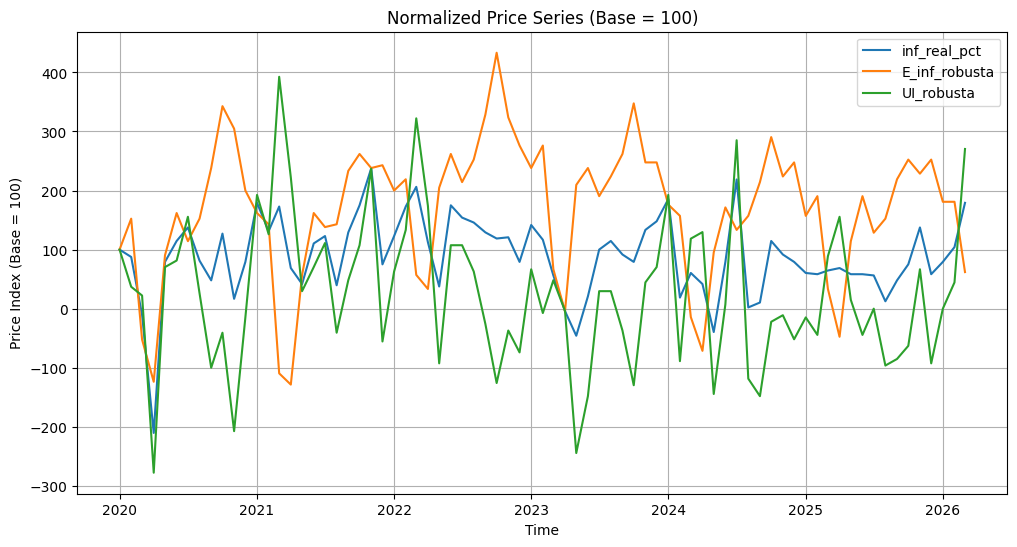

In [43]:
# Unexpected changes in inflation 
rrm.plot_normalized_timeseries_def_columns(['UN_INF', 'UN_INF', 'UN_INF'], ['inf_real_pct', 'E_inf_robusta', 'UI_robusta'], legend = 'Columns')

No data available for UDI20


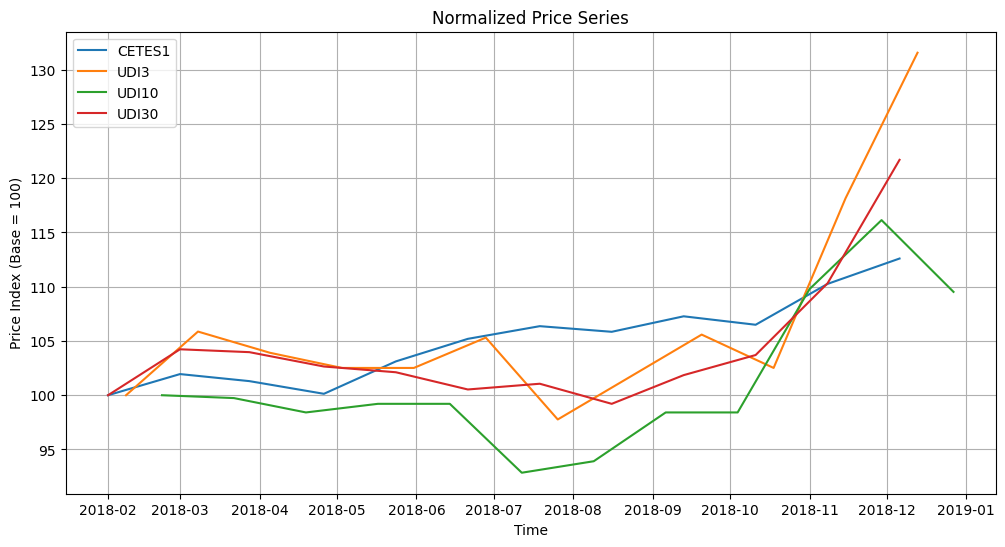

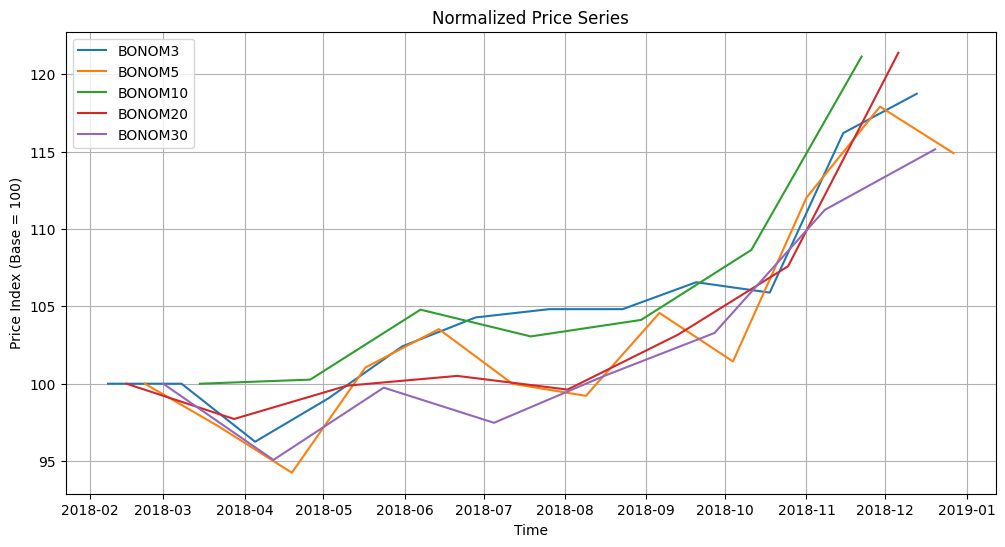

In [73]:
# Shifts in the yield curve
rrm.plot_normalized_timeseries(['CETES1', 'UDI3', 'UDI10', 'UDI20', 'UDI30'], from_date='2018-01-01', to_date='2018-12-31')
rrm.plot_normalized_timeseries(['BONOM3', 'BONOM5', 'BONOM10', 'BONOM20', 'BONOM30'], from_date='2018-01-01', to_date='2018-12-31')

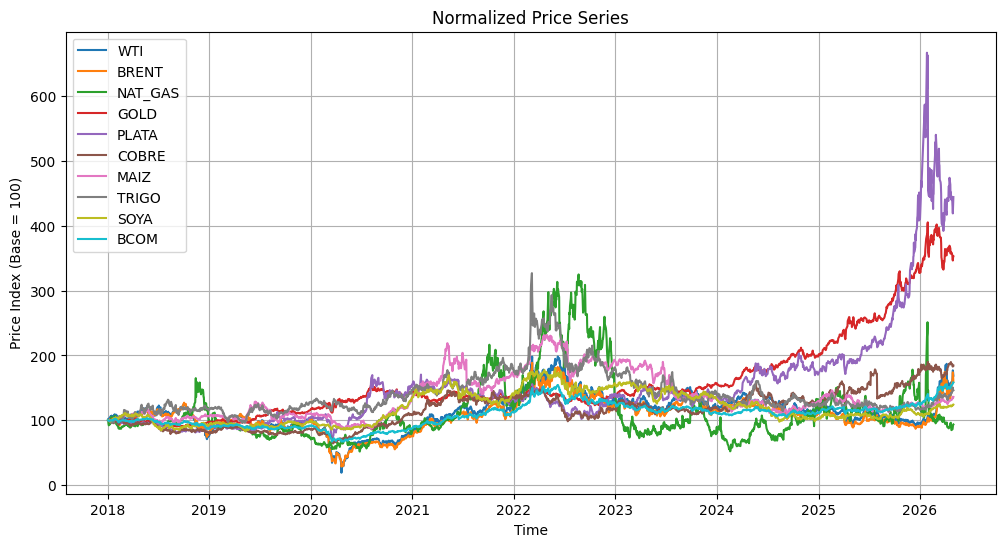

In [68]:
# COMODITIES
rrm.plot_normalized_timeseries(['WTI', 'BRENT', 'NAT_GAS', 'GOLD', 'PLATA', 'COBRE', 'MAIZ', 'TRIGO', 'SOYA', 'BCOM'])

### Assumptions

# Marco Analítico: Búsqueda de Poder Explicativo en Ventanas Temporales Deslizantes

El presente análisis emplea un modelo de regresión lineal simple sobre variables estandarizadas, cuyo objetivo central no es la predicción puntual, sino la **cuantificación sistemática del poder explicativo que una variable ejerce sobre otra a lo largo del tiempo**.

La métrica principal es el coeficiente de determinación r^2, complementado por un Score ponderado que ajusta dicho r^2 por el número de observaciones disponibles en cada ventana, penalizando así las relaciones espurias derivadas de muestras reducidas.

La arquitectura de búsqueda opera mediante ventanas temporales deslizantes no superpuestas en su punto de inicio, generando todas las combinaciones posibles de pares de meses dentro de un año calendario. Para el caso mensual (2018, 2020, 2023, 2025), esto implica construir regresiones desde el par enero–febrero hasta el par noviembre–diciembre, acumulando observaciones progresivamente. 

El criterio mínimo de validez es una ventana de aproximadamente 60 días hábiles de mercado (aprox. 3 meses), garantizando robustez estadística. Para el análisis anual se requieren al menos 200 observaciones por ventana, y para 2026 dada la escasez de datos intra-año la división se reduce a comparaciones semanales con un mínimo de un mes de observaciones.

Los resultados se clasifican en dos bloques por período:

* Principal: el activo que aparece como la variable dependiente con mayor frecuencia de presencia como "benchmark líder" a través de todas las ventanas válidas del período. Representa la relación más consistente y estructural identificada.
* Complemento: los demás activos analizados que, en ese mismo período, exhiben relaciones explicativas secundarias pero estadísticamente relevantes, o cuya presencia parcial sugiere regímenes condicionados.

El uso de UNEXPECTED INFLATION puede ser limitado, casi nulo (B1=0) independientemente de que activo/indices se ocupe para y
Buscar de nuevo la informacion de bonos M, udibonos
Commodities sirven
EXP_INF DE USA Y MX ACTUAL, TIPS, DGS
Index sirven


Dado que nuestra función que busca el mejor r2 fue construida con complejidad algorítmica exponencial O(n^2), los benchmarks serán aplicados por sección de indices, commodities, tasas, etc.

Before starting, let´s see if the unexpected inflation information built is significative for some assets as monthly returns of BBVA, DXY and USDMXN over a simple linear regression model due the small sample that we have at the moment.

Formally, we will check if assuptions are satisfied to make properly the test for b1 (slope). 

Predicted b1 by the model: 1.47978
T test - t* de b1 : 61.62817208892141
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 61.62817208892141 > 1.9610804471015861
Se rechaza H0 ( b1  <=  0 ) tq b1 > 0 ya que 61.62817208892141 > 1.6455706718157985


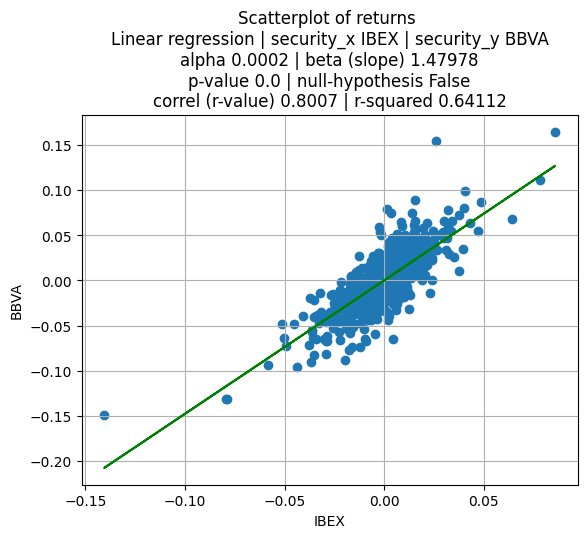

In [27]:
model = rrm.model('IBEX', 'BBVA', model_type='macro')
model.synchronise_timeseries()
model.compute_linear_reg()
model.plot_linear_reg()
# The assuptions were satisfied but normality.
model.estimator_tests('b1', 0)

For the assets of interest (BBVA, DXY and USDMXN) all get a b1 = 0, meaning that the model is not appropiated.

In [ ]:
# Falta iferencial entre tasa reales y nominales de MX VS EUA y Unexpected para EUA
# No funciona con: 'UI_MX', 'CETES1', 'UDI3', ademas con: 'UDI10', 'UDI20', 'UDI30', 'BONOM3', 'BONOM5', 'BONOM10', 'BONOM20', 'BONOM30'

commodities_benchmarks = ['WTI', 'BRENT', 'NAT_GAS', 'GOLD', 'PLATA', 'COBRE', 'MAIZ', 'TRIGO', 'SOYA', 'BCOM'] 
assets = ['USDMXN', 'DXY']

In [123]:
r2_2018_commodities= rrm.buscar_mejor_r2(x = commodities_benchmarks, y = assets, start_date='2018-01-04', end_date='2018-12-31', min_obs = 80, min_corr=0.3)

In [124]:
# 1. Análisis
r2_2018_p_comm, r2_2018_c_comm = rrm.analizar_todo_el_df(r2_2018_commodities)

# 2. Resumen rápido
rrm.imprimir_resumen_frecuencias(r2_2018_commodities)

# 3. Desglose detallado de TODO
rrm.imprimir_desglose_total(r2_2018_p_comm, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
rrm.imprimir_desglose_total(r2_2018_c_comm, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: DXY (80.25% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: DXY | Bench: COBRE
 > Score: 0.8327 | R2: 0.1879
 > Periodo: 2018-02-01 a 2018-06-01


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: DXY (Total obs: 65)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: COBRE
      Frecuencia: 24 [36.92% del security]
      📉 Min R2: 0.0955 [r: -0.3091] (Score: 0.4918)
         Periodo: 2018-03-01 a 2018-11-01
      📈 Max R2: 0.1879 [r: -0.4335] (Score: 0.8327)
         Periodo: 2018-02-01 a 2018-06-01
      ····························································
   🔸 Benchmark: PLATA
      Frecuencia: 21 [32.31% del security]
      📉 Min R2: 0.1165 [r

The commodities of interest must satisfied at least the assuptions to get an explication signifcative, if it does not the case then there is not enough evidence of significance or impact of the commodity in the asset.

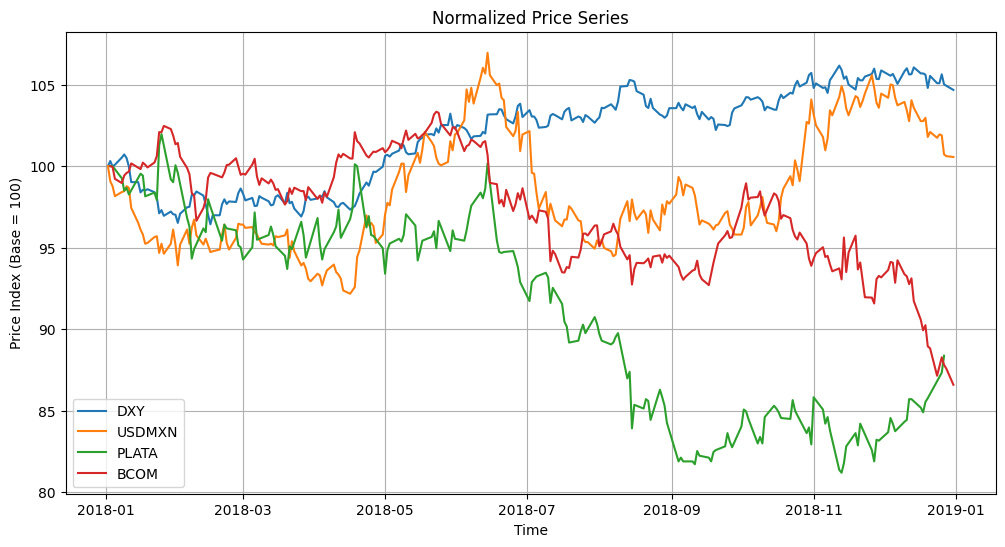

In [126]:
rrm.plot_normalized_timeseries(['DXY', 'USDMXN', 'PLATA','BCOM'], from_date = '2018-01-01', to_date='2018-12-31')

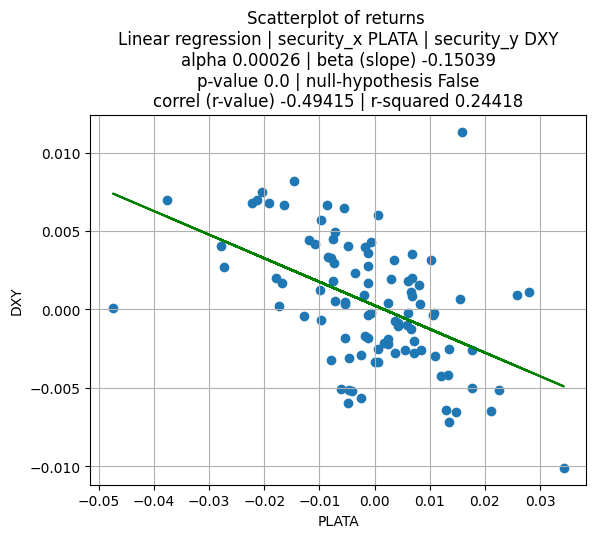

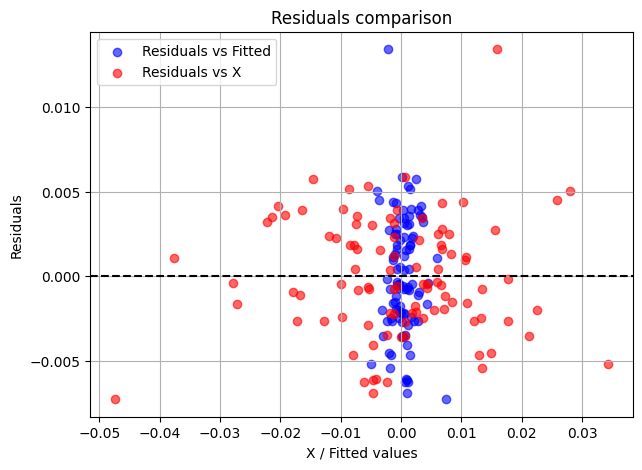

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.62141
→ NO se rechaza H0: varianza constante

NORMALIDAD (Shapiro-Wilk):
p-value: 0.03575
→ Se RECHAZA H0: residuos NO normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.12598
→ Sin evidencia de autocorrelación

Predicted b1 by the model: -0.15039
T test - t* de b1 : -5.568951917806087
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 5.568951917806087 > 1.9849843115310182
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -5.568951917806087 < 1.6608814403008005


In [153]:
dxy_silver = rrm.model('PLATA', 'DXY', model_type='macro')
dxy_silver.synchronise_timeseries(from_date ='2018-01-02', to_date='2018-6-29') # from_date ='2018-07-02', to_date='2018-11-29'
dxy_silver.compute_linear_reg()
dxy_silver.plot_linear_reg()
dxy_silver.linealidad()
dxy_silver.homocedasticidad()
dxy_silver.normalidad()
dxy_silver.independencia()
dxy_silver.estimator_tests('b1')

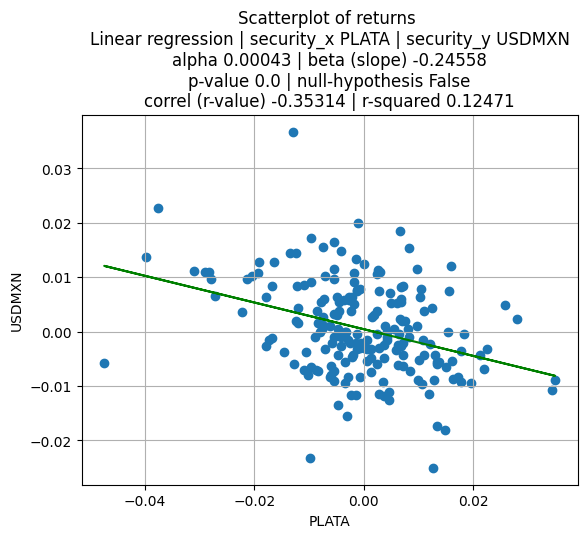

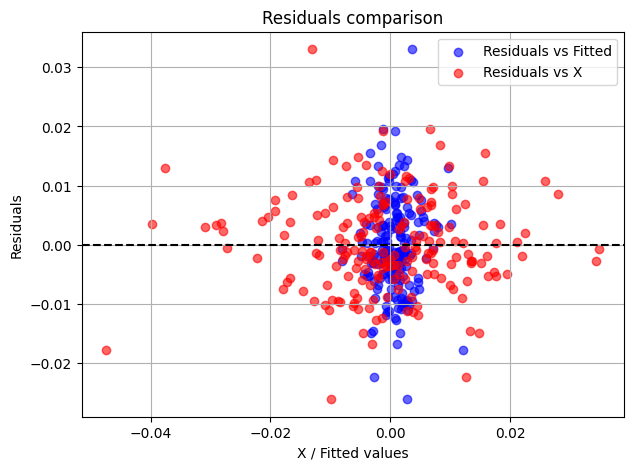

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.21801
→ NO se rechaza H0: varianza constante

NORMALIDAD (Shapiro-Wilk):
p-value: 0.07019
→ NO se rechaza H0: residuos normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.16253
→ Sin evidencia de autocorrelación

Predicted b1 by the model: -0.24558
T test - t* de b1 : -5.270906690478662
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 5.270906690478662 > 1.9722040512658325
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -5.270906690478662 < 1.6527053097707547


In [155]:
usdmxn_silver = rrm.model('PLATA', 'USDMXN', model_type='macro')
usdmxn_silver.synchronise_timeseries(from_date ='2018-01-01', to_date='2018-12-29')
usdmxn_silver.compute_linear_reg()
usdmxn_silver.plot_linear_reg()
usdmxn_silver.linealidad()
usdmxn_silver.homocedasticidad()
usdmxn_silver.normalidad()
usdmxn_silver.independencia()
usdmxn_silver.estimator_tests('b1')

In [158]:
index_benchmarks = ['IBEX', 'SPX', 'MXX', 'NASDAQC']
r2_2018_index = rrm.buscar_mejor_r2(x = index_benchmarks, y = assets, start_date='2018-01-04', end_date='2018-12-31', min_obs = 80, min_corr=0.3)

In [159]:
# 1. Análisis
r2_2018_p_index, r2_2018_c_index = rrm.analizar_todo_el_df(r2_2018_index)

# 2. Resumen rápido
rrm.imprimir_resumen_frecuencias(r2_2018_index)

# 3. Desglose detallado de TODO
rrm.imprimir_desglose_total(r2_2018_p_index, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
rrm.imprimir_desglose_total(r2_2018_c_index, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: USDMXN (60.00% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: USDMXN | Bench: MXX
 > Score: 1.1106 | R2: 0.2493
 > Periodo: 2018-08-01 a 2018-11-30


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: USDMXN (Total obs: 21)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: MXX
      Frecuencia: 13 [61.90% del security]
      📉 Min R2: 0.1076 [r: -0.3280] (Score: 0.5650)
         Periodo: 2018-02-01 a 2018-11-01
      📈 Max R2: 0.2493 [r: -0.4993] (Score: 1.1106)
         Periodo: 2018-08-01 a 2018-11-30
      ····························································
   🔸 Benchmark: SPX
      Frecuencia: 7 [33.33% del security]
      📉 Min R2: 0.0941 

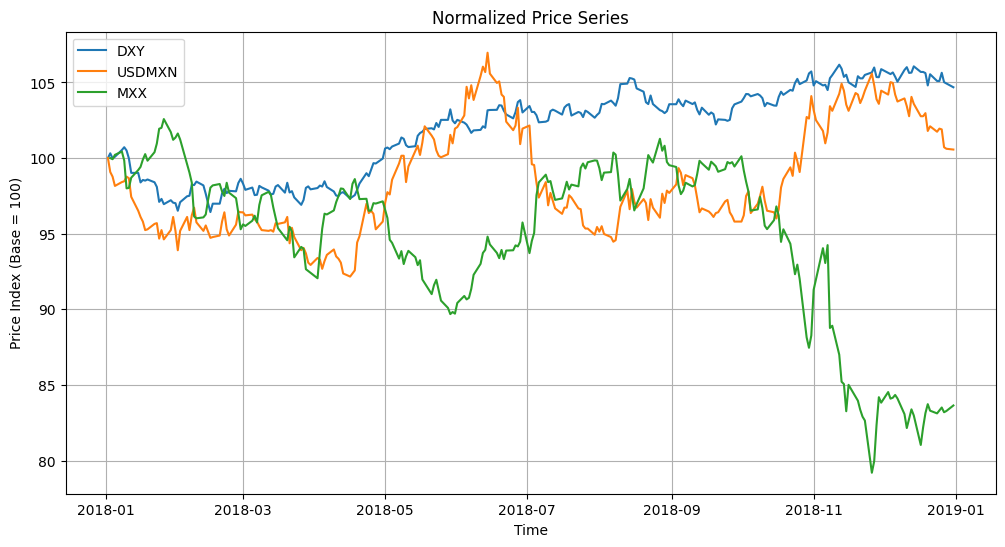

In [143]:
rrm.plot_normalized_timeseries(['DXY', 'USDMXN', 'MXX'], from_date = '2018-01-01', to_date='2018-12-31')

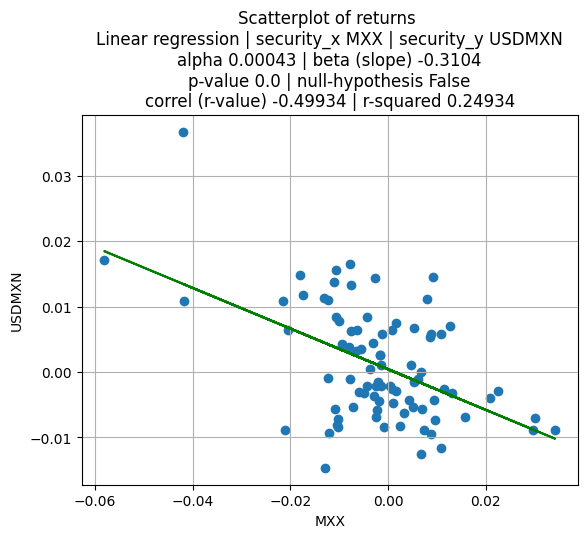

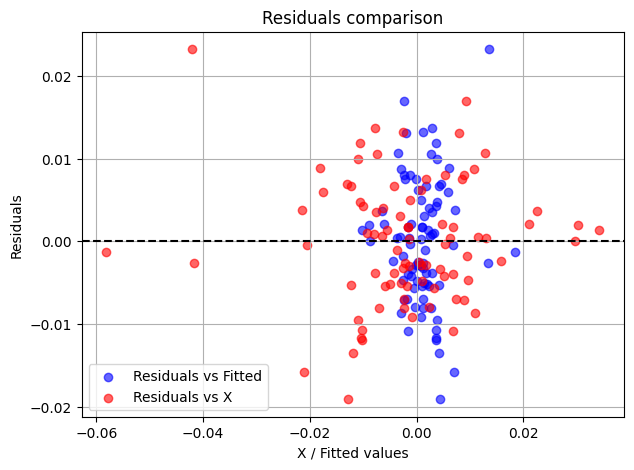

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.00550
→ Se RECHAZA H0: hay heterocedasticidad (varianza NO constante)

NORMALIDAD (Shapiro-Wilk):
p-value: 0.96098
→ NO se rechaza H0: residuos normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.39501
→ Sin evidencia de autocorrelación

Predicted b1 by the model: -0.3104
T test - t* de b1 : -5.282085270343771
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 5.282085270343771 > 1.9886096669757087
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -5.282085270343771 < 1.6631966790019561


In [ ]:
mxx_usdmxn = rrm.model('MXX', 'USDMXN', model_type='macro')
mxx_usdmxn.synchronise_timeseries(from_date ='2018-08-01', to_date='2018-11-30')
mxx_usdmxn.compute_linear_reg()
mxx_usdmxn.plot_linear_reg()
mxx_usdmxn.linealidad()
mxx_usdmxn.homocedasticidad()
mxx_usdmxn.normalidad()
mxx_usdmxn.independencia()
mxx_usdmxn.estimator_tests('b1')

### MXX vs USDMXN
Linealidad: parcialmente. La línea no está mal ajustada en el centro, pero hay varios problemas visibles:
1. Heterocedasticidad clara. Los residuos no tienen varianza constante. En la zona central (MXX cerca de 0) los puntos están muy dispersos verticalmente, mientras en los extremos se comprime. Eso viola el supuesto de homocedasticidad, que es un primo directo de la linealidad en regresión.
2. Outlier severo en la esquina superior izquierda. Ese punto aislado (MXX ≈ -0.06, USDMXN ≈ +0.036) está jalando la línea significativamente. Con solo 75-80 observaciones ese punto tiene palanca alta y está inflando artificialmente la pendiente negativa y el r² (0.249 en realidad se ve alto dado la nube de puntos).
3. La nube central es casi un círculo. Si tapas los outliers de los extremos, el resto de los puntos no muestran ninguna tendencia clara. La relación lineal la está "construyendo" principalmente los extremos, no la masa de datos.

El supuesto de linealidad se cumple débilmente. La relación existe pero es muy ruidosa (r2 de 0.25 con heterocedasticidad significa que en la práctica el modelo en el centro del rango no predice bien).

Winsorizar o eliminar el outlier extremo y recorrer la regresión para ver cuánto cambia el beta — si cambia mucho, tienes un problema de robustez.
Aplicar errores estándar robustos a heterocedasticidad (HC3 o Newey-West si hay autocorrelación).
Considerar si la relación es no lineal en los extremos — en crisis (MXX muy negativo) el dólar reacciona de forma no proporcional, lo que rompería la linealidad global.


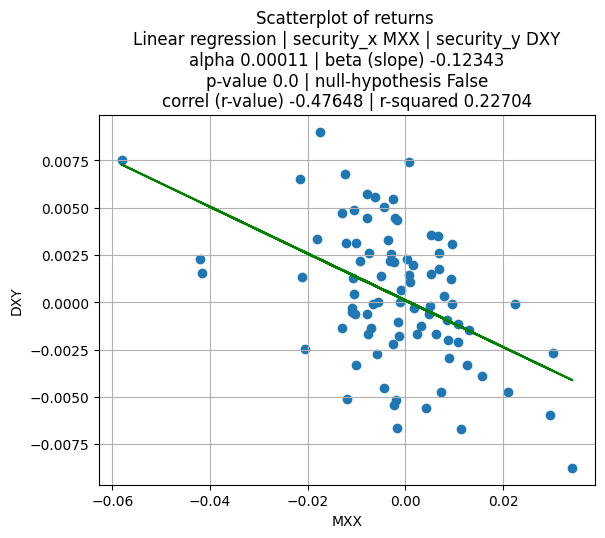

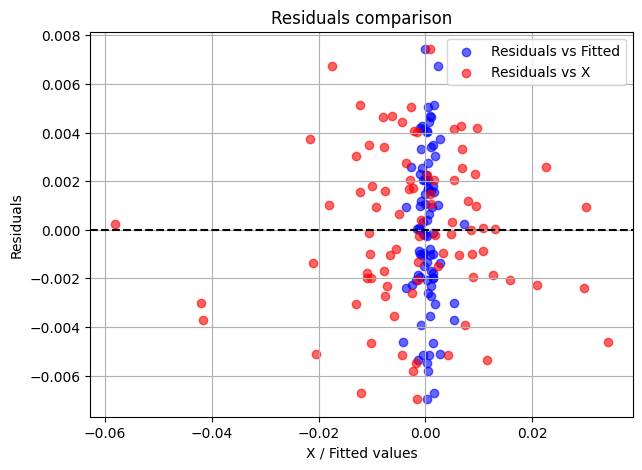

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.41152
→ NO se rechaza H0: varianza constante

NORMALIDAD (Shapiro-Wilk):
p-value: 0.70621
→ NO se rechaza H0: residuos normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.06786
→ Sin evidencia de autocorrelación

Predicted b1 by the model: -0.12343
T test - t* de b1 : -4.9672445906109095
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 4.9672445906109095 > 1.9886096669757087
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -4.9672445906109095 < 1.6631966790019561


In [150]:
mxx_dxy = rrm.model('MXX', 'DXY', model_type='macro')
mxx_dxy.synchronise_timeseries(from_date ='2018-08-01', to_date='2018-11-30')
mxx_dxy.compute_linear_reg()
mxx_dxy.plot_linear_reg()
mxx_dxy.linealidad()
mxx_dxy.homocedasticidad()
mxx_dxy.normalidad()
mxx_dxy.independencia()
mxx_dxy.estimator_tests('b1')

### MXX vs DXY 
Parece cumplir supuestos pero...
Lo que mejora vs el gráfico MXX → USDMXN ✓
La nube es más simétrica y homogénea. Los puntos están mejor distribuidos alrededor de la línea en toda la extensión del eje X. La heterocedasticidad que era tan evidente en el anterior aquí es más moderada — la dispersión vertical en el centro es más parecida a la de los extremos.
Los outliers son menos dañinos. El punto extremo izquierdo (MXX ≈ -0.06) sigue ahí, pero su DXY correspondiente (≈ +0.0075) no es tan exagerado en escala relativa. En el gráfico anterior ese punto estaba claramente fuera del rango normal; aquí entra más dentro de la estructura general.

Lo que se mantiene preocupante ✗
El mismo problema de fondo: la masa central de puntos (MXX entre -0.01 y +0.01) sigue siendo una nube casi circular. La tendencia lineal la construyen principalmente los extremos.
r² de 0.227 — prácticamente igual al anterior (0.249). El DXY no explica mucho más ni mucho menos que el USDMXN en su relación con el MXX.
El beta es más pequeño (-0.123 vs -0.310), lo cual tiene sentido: el DXY es un índice del dólar contra una canasta de 6 monedas, por lo que el peso mexicano diluye su efecto. USDMXN es más sensible al MXX que el DXY en términos absolutos.


### Conclusiones
El DXY se comporta marginalmente mejor en términos de supuestos, pero ninguno de los dos pasa limpio un test de linealidad formal como RESET de Ramsey.

La pregunta de fondo para tu APT
¿Cuál es tu variable dependiente — USDMXN o DXY? Porque si tu objetivo es explicar el tipo de cambio peso-dólar, el USDMXN es el target correcto aunque tenga más ruido, ya que el DXY te estaría diluyendo el fenómeno que te interesa. El DXY podría ser más útil como factor explicativo (variable X) dentro del APT, no como el activo a explicar.

In [145]:
macro_rates_benchmarks = ['TIPS5', 'TIPS10', 'EXP_INF_USA5', 'EXP_INF_USA10', 'EXP_INF_MX3', 'EXP_INF_MX10']

r2_2018_macro = rrm.buscar_mejor_r2(x = macro_rates_benchmarks, y = assets, start_date='2018-01-04', end_date='2018-12-31', min_obs = 80, min_corr=0.3)

In [148]:
# 1. Análisis
r2_2018_p_macro, r2_2018_c_macro = rrm.analizar_todo_el_df(r2_2018_macro)

# 2. Resumen rápido
rrm.imprimir_resumen_frecuencias(r2_2018_macro)

# 3. Desglose detallado de TODO
rrm.imprimir_desglose_total(r2_2018_p_macro, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
rrm.imprimir_desglose_total(r2_2018_c_macro, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: USDMXN (97.92% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: USDMXN | Bench: EXP_INF_MX10
 > Score: 1.8783 | R2: 0.3734
 > Periodo: 2018-04-02 a 2018-11-01


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: USDMXN (Total obs: 47)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: EXP_INF_MX10
      Frecuencia: 28 [59.57% del security]
      📉 Min R2: 0.2194 [r: 0.4684] (Score: 1.0949)
         Periodo: 2018-02-01 a 2018-08-31
      📈 Max R2: 0.3986 [r: 0.6313] (Score: 1.7754)
         Periodo: 2018-08-01 a 2018-11-30
      ····························································
   🔸 Benchmark: EXP_INF_MX3
      Frecuencia: 19 [40.43% del security

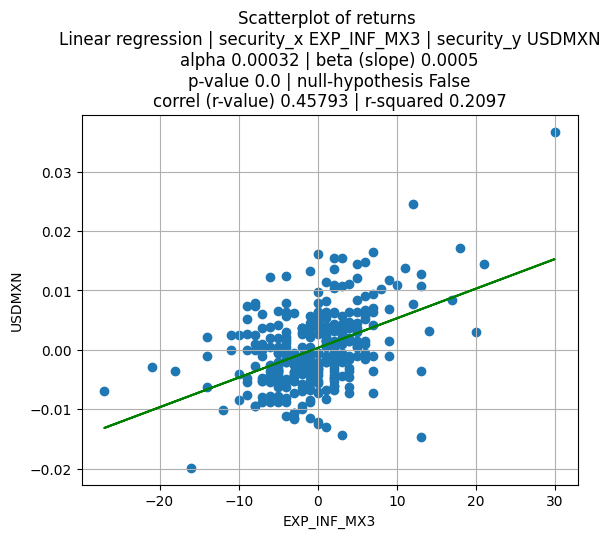

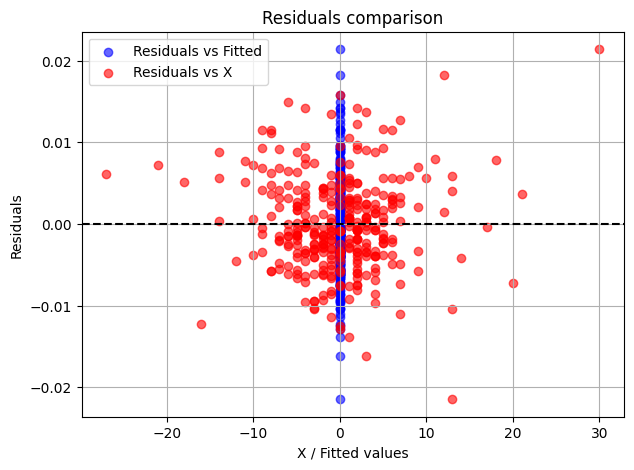

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.00109
→ Se RECHAZA H0: hay heterocedasticidad (varianza NO constante)

NORMALIDAD (Shapiro-Wilk):
p-value: 0.01261
→ Se RECHAZA H0: residuos NO normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.20760
→ Sin evidencia de autocorrelación

Predicted b1 by the model: 0.0005
T test - t* de b1 : 9.3978660027754
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 9.3978660027754 > 1.9671350567188735
Se rechaza H0 ( b1  <=  0 ) tq b1 > 0 ya que 9.3978660027754 > 1.649456204654707


In [167]:
inf_mx_usdmxn = rrm.model('EXP_INF_MX3', 'USDMXN', model_type='macro')
inf_mx_usdmxn.synchronise_timeseries(from_date ='2018-08-01', to_date='2019-12-01')
inf_mx_usdmxn.compute_linear_reg()
inf_mx_usdmxn.plot_linear_reg()
inf_mx_usdmxn.linealidad()
inf_mx_usdmxn.homocedasticidad()
inf_mx_usdmxn.normalidad()
inf_mx_usdmxn.independencia()
inf_mx_usdmxn.estimator_tests('b1')

Analizando los supuestos observamos lo siguiente:
Antes del periodo    →  supuestos OK, R² bajo     →  no hay relación
Durante el periodo   →  supuestos fallan, R² alto  →  relación existe pero es no lineal o inestable
Después del periodo  →  supuestos OK, R² bajo      →  relación desapareció



Eso no es un modelo roto. Es un régimen transitorio. La relación existió, fue intensa, pero fue no lineal durante ese periodo — probablemente porque el mercado estaba en modo de ajuste violento (post-elección, NAICM, volatilidad del peso en mínimos históricos ese año). Los mercados en stress no se comportan linealmente.

Qué harías con esto
Opción 1 — Aceptar el hallazgo como régimen específico. Documentas que la relación USDMXN-Breakeven existió en ese periodo bajo condiciones de stress político-económico particular, pero no es una relación estructural estable. Eso tiene valor académico y práctico.
Opción 2 — Explorar no linealidad. Si dentro del subperiodo la homocedasticidad falla, considera si una transformación adicional o un modelo de umbral (threshold) captura mejor esa dinámica.
Opción 3 — Cambiar el target. Tu intuición es correcta. El breakeven de inflación a 3 años explicando USDMXN es una relación de segundo orden — el mercado de bonos indexados en México es relativamente ilíquido, entonces el breakeven puede moverse por razones técnicas más que por expectativas puras. Ese mismo factor podría explicar mejor activos más directamente ligados a inflación como Udibonos, TIIE, o incluso el propio INPC realizado. O bien activos sectoriales como bancos (BBVA, Banorte) que son sensibles a tasas.

In [170]:
# 1. Generar el análisis de temporalidad para todos los pares
# Esta función te devolverá un DataFrame con los mejores periodos de cada relación
df_temporalidad_2018 = rrm.analizar_temporalidad_todos_los_pares(r2_2018_macro)

# 2. Imprimir los resultados de forma legible en la consola
rrm.imprimir_mejores_periodos(df_temporalidad_2018)

# 3. (Opcional) Si quieres ver solo los top 5 con mayor score temporal de todo el año
print("\nTOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:")
print(df_temporalidad_2018.nlargest(5, 'score_temporal'))


◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈
                  MEJORES VENTANAS TEMPORALES (R2 x DURACIÓN)                   
◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

📊 SECURITY: DXY
   ▫ Bench: EXP_INF_MX3     | R2: 0.0927 | Días: 151 | Periodo: 2018-07-02 ➜ 2018-11-30

📊 SECURITY: USDMXN
   ▫ Bench: EXP_INF_MX10    | R2: 0.3009 | Días: 302 | Periodo: 2018-02-01 ➜ 2018-11-30
   ▫ Bench: EXP_INF_MX3     | R2: 0.1672 | Días: 302 | Periodo: 2018-02-01 ➜ 2018-11-30

◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

TOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:
  security     benchmark        r2  duracion_dias  score_temporal       from  \
1   USDMXN  EXP_INF_MX10  0.300877            302       90.864854 2018-02-01   
2   USDMXN   EXP_INF_MX3  0.167166            302       50.484132 2018-02-01   
0      DXY   EXP_INF_MX3  0.092692            151       13.996492 2018-07-02   

          to


██████████████████████████████████████████████████████████████████████
       PIPELINE KAN-ZHANG (1999) — DETECCIÓN DE FACTORES ÚTILES       
                   Período: 2026-01-01 → 2026-04-20                   
██████████████████████████████████████████████████████████████████████

⟹  PASO 0: Multicolinealidad entre factores

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
              DIAGNÓSTICO 0: CORRELACIÓN ENTRE FACTORES               
                   Periodo: 2026-01-01 a 2026-04-20                   
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  HYG             vs VIX             | r=-0.6792 | p=0.0000 | N= 74 | ✅ OK
  EXP_INF_USA5    vs BRENT           | r= 0.6765 | p=0.0000 | N= 74 | ✅ OK
  TIPS5           vs HYG             | r=-0.4031 | p=0.0004 | N= 74 | ✅ OK
  BRENT           vs VIX             | r= 0.3095 | p=0.0065 | N= 76 | ✅ OK
  EXP_INF_USA5    vs HYG             | r=-0.2913 | p=0.0118 | N= 74 | ✅ OK
  BRENT   

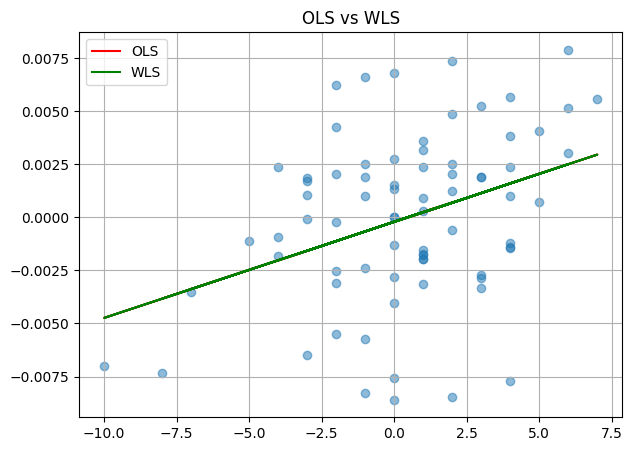

     [Diag 2] R2_OLS=0.1302 | R2_WLS=0.1302 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=3.3079 | t_EIV=3.3079 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 TIPS5 → DXY

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -2.810792255934701e-05
Beta: 0.00011297007566860307

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.10352
→ NO se rechaza H0: varianza constante



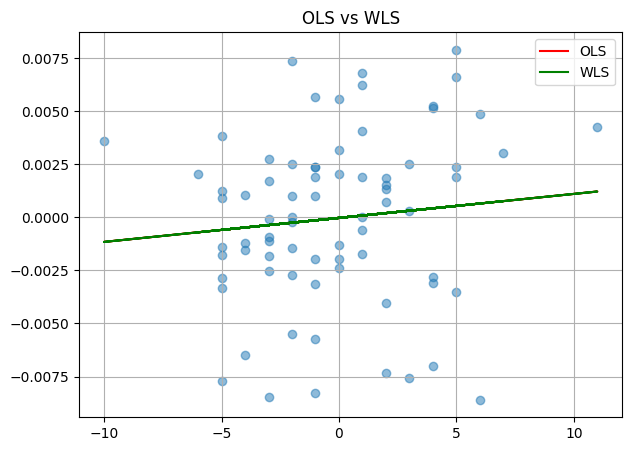

     [Diag 2] R2_OLS=0.0256 | R2_WLS=0.0224 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=1.3834 | t_EIV=1.3834 | ❌ No significativo en ambos
     [Diag 4] 🟡 SEÑAL DÉBIL (mismo signo pero no ambas sig.)

  📊 BRENT → DXY

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.000242121865439031
Beta: 0.031105368161390704

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.39683
→ NO se rechaza H0: varianza constante



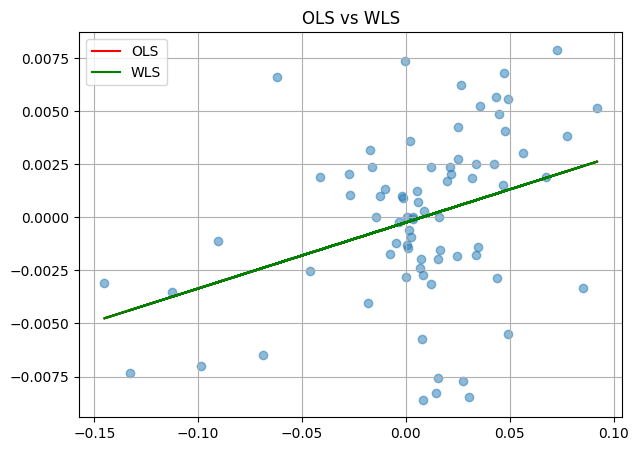

     [Diag 2] R2_OLS=0.1243 | R2_WLS=0.1243 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=3.2407 | t_EIV=2.6445 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 HYG → DXY

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -4.9773601142147155e-05
Beta: -0.6025401786289186

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.84585
→ NO se rechaza H0: varianza constante



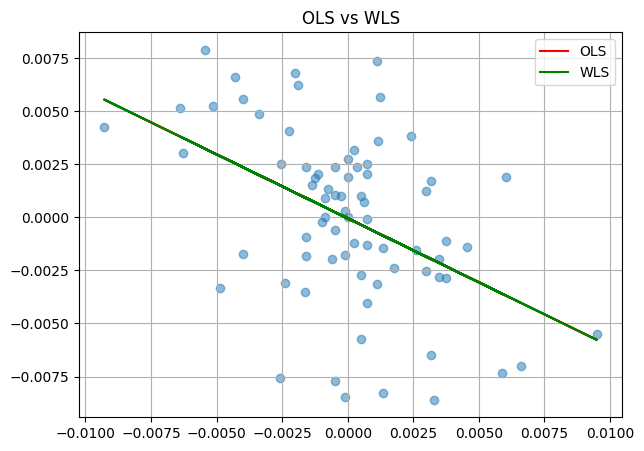

     [Diag 2] R2_OLS=0.2162 | R2_WLS=0.2162 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=-4.4569 | t_EIV=-0.0232 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] 🟡 SEÑAL DÉBIL (mismo signo pero no ambas sig.)

  📊 VIX → DXY

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -9.863232335680581e-05
Beta: 0.012273344009915572

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.87923
→ NO se rechaza H0: varianza constante



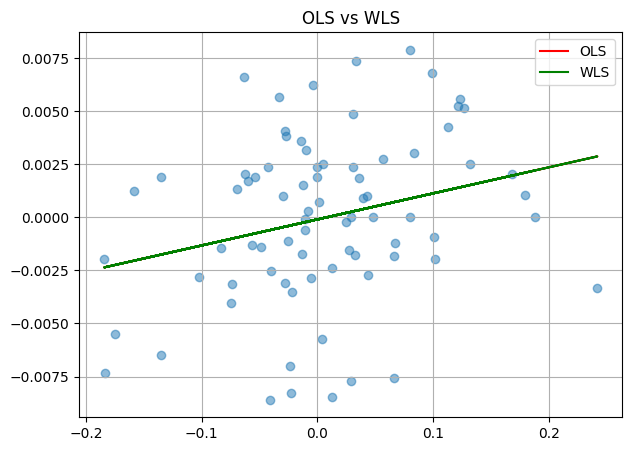

     [Diag 2] R2_OLS=0.0754 | R2_WLS=0.0752 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=2.4737 | t_EIV=2.4445 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 EXP_INF_USA5 → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.0008201105151905794
Beta: 0.0004489833580121002

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.78593
→ NO se rechaza H0: varianza constante



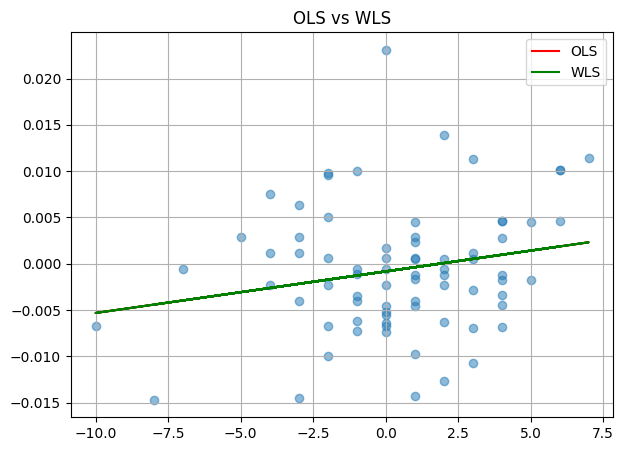

     [Diag 2] R2_OLS=0.0451 | R2_WLS=0.0451 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=1.8576 | t_EIV=1.8576 | ❌ No significativo en ambos
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 TIPS5 → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.0006369422146188169
Beta: 0.00011745382465839309

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.49491
→ NO se rechaza H0: varianza constante



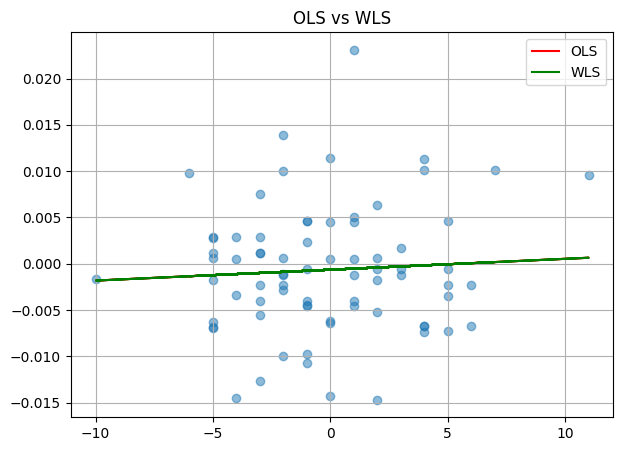

     [Diag 2] R2_OLS=0.0104 | R2_WLS=0.0088 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=0.8762 | t_EIV=0.8762 | ❌ No significativo en ambos
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 BRENT → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.000993609155404308
Beta: 0.05190281302543293

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.25402
→ NO se rechaza H0: varianza constante



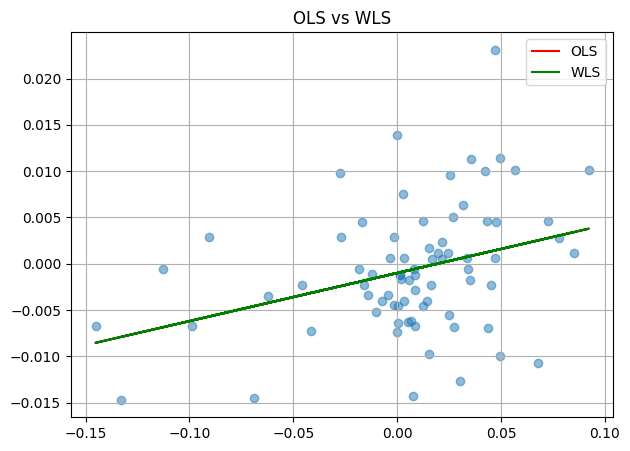

     [Diag 2] R2_OLS=0.1216 | R2_WLS=0.1215 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=3.2005 | t_EIV=2.0471 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 HYG → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.0006490692065628508
Beta: -1.262065962830318

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.63032
→ NO se rechaza H0: varianza constante



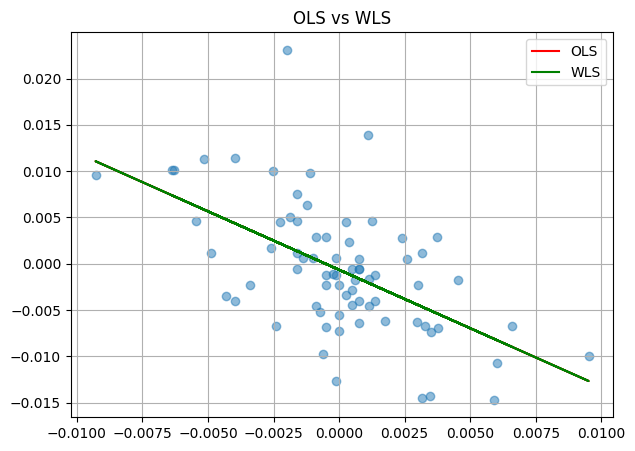

     [Diag 2] R2_OLS=0.3239 | R2_WLS=0.3239 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=-5.873 | t_EIV=-0.0146 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] 🟡 SEÑAL DÉBIL (mismo signo pero no ambas sig.)

  📊 VIX → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.0008026487947614845
Beta: 0.059089001628417556

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.00082
→ Se RECHAZA H0: hay heterocedasticidad (varianza NO constante)



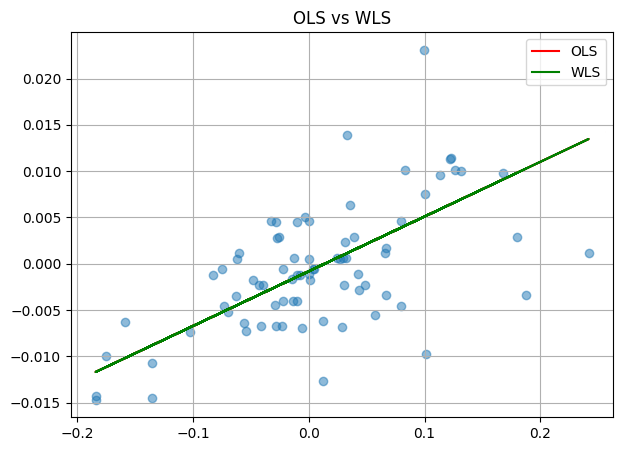

     [Diag 2] R2_OLS=0.3594 | R2_WLS=0.3416 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=6.5297 | t_EIV=5.6401 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

══════════════════════════════════════════════════════════════════════
                   RESUMEN FINAL — RECOMENDACIONES                    
══════════════════════════════════════════════════════════════════════
  VIX             → USDMXN     | Puntaje: 5/6 | 🟢 USAR
  EXP_INF_USA5    → DXY        | Puntaje: 3/6 | 🟡 CON CAUTELA
  BRENT           → DXY        | Puntaje: 3/6 | 🟡 CON CAUTELA
  VIX             → DXY        | Puntaje: 3/6 | 🟡 CON CAUTELA
  BRENT           → USDMXN     | Puntaje: 3/6 | 🟡 CON CAUTELA
  HYG             → DXY        | Puntaje: 2/6 | 🟡 CON CAUTELA
  EXP_INF_USA5    → USDMXN     | Puntaje: 2/6 | 🟡 CON CAUTELA
  HYG             → USDMXN     | Puntaje: 2/6 | 🟡 CON CAUTELA
  TIPS5           → DXY        | Puntaje: 0/6 | 🔴 DES

In [11]:
# ── EN TU NOTEBOOK, EL FLUJO CORRECTO ES ─────────────────────

from_date = '2026-01-01'
to_date   = '2026-04-20'

benchmarks_x  = ['EXP_INF_USA5', 'TIPS5', 'BRENT', 'HYG', 'VIX']
securities_y  = ['DXY', 'USDMXN']

# ── PASO 0-4: Diagnóstico completo Kan-Zhang ──────────────────
df_kz, usar, cautela, descartar = rrm.pipeline_kan_zhang(
    benchmarks_x, securities_y,
    from_date, to_date,
    significance=0.05,
    umbral_corr_factores=0.7,
    min_obs=20
)

# ── SOLO CON LOS FACTORES QUE PASARON EL FILTRO ──────────────
benchmarks_filtrados = usar + cautela  # excluyes 'descartar'

r2_2026 = rrm.buscar_mejor_r2(
    x=benchmarks_filtrados,
    y=securities_y,
    freq='W-FRI',
    start_date=from_date,
    end_date=to_date,
    min_obs=20,
    min_corr=0
)

# ── LUEGO TU ANÁLISIS HABITUAL ────────────────────────────────
rrm.imprimir_resumen_frecuencias(r2_2026)
df_temp = rrm.analizar_temporalidad_todos_los_pares(r2_2026)
rrm.imprimir_mejores_periodos(df_temp)

2018: TIPS no aparece como líder (EXP_INF domina, ciclo de normalización)
2020: TIPS distorsionado por crisis de liquidez (factor ruido transitorio)
2023: TIPS DOMINA (desinflación + política restrictiva = señal limpia)
2025: TIPS debilitado (aranceles = ambigüedad inflación/política)
2026: TIPS irrelevante (geopolítica domina, canal roto)

Esto es coherente con lo que Kan-Zhang llamaría un factor que oscila entre genuino e inútil dependiendo del régimen. En 2023 TIPS5 pasaría todos sus diagnósticos con puntaje 6/6. En 2026 los falla todos.

Se añadió una función de nota con respecto a N pequeño y la distribución del R2
Se añadió una mejora de la comparativa entre WLS vs OLS usando GLS AR1
Se añadió 

Posteriormente a esto podemos empezar a implementar las funciones de busqueda de fechas especificas que la contengan, de inicio y final
def consultar_fecha_especifica(df, fecha_buscada):
Pasandole el df construido sobre la anterior funcion que seria r2_2026



██████████████████████████████████████████████████████████████████████
       PIPELINE KAN-ZHANG (1999) — DETECCIÓN DE FACTORES ÚTILES       
                   Período: 2023-01-01 → 2023-12-31                   
██████████████████████████████████████████████████████████████████████

⟹  PASO 0: Multicolinealidad entre factores

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
              DIAGNÓSTICO 0: CORRELACIÓN ENTRE FACTORES               
                   Periodo: 2023-01-01 a 2023-12-31                   
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  HYG             vs VIX             | r=-0.5092 | p=0.0000 | N=250 | ✅ OK
  TIPS5           vs HYG             | r=-0.4442 | p=0.0000 | N=249 | ✅ OK
  EXP_INF_USA5    vs BRENT           | r= 0.3731 | p=0.0000 | N=249 | ✅ OK
  EXP_INF_USA5    vs VIX             | r=-0.1257 | p=0.0472 | N=250 | ✅ OK
  TIPS5           vs VIX             | r=-0.0653 | p=0.3040 | N=250 | ✅ OK
  EXP_INF_

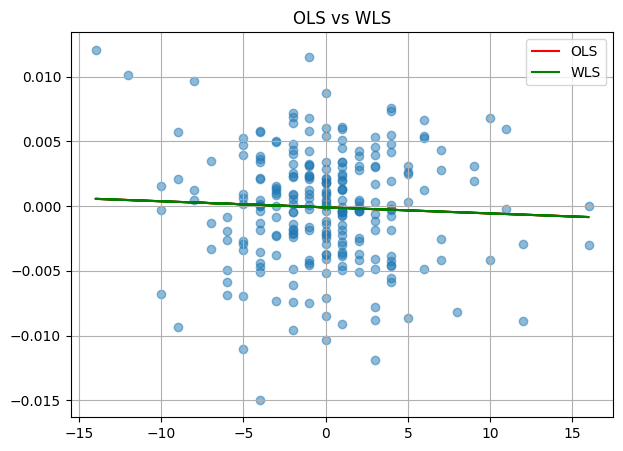

     [Diag 2] R2_OLS=0.0021 | R2_WLS=0.0021 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=-0.7318 | t_EIV=-0.7318 | ❌ No significativo en ambos
     [Diag 4] 🟡 SEÑAL DÉBIL (mismo signo pero no ambas sig.)

  📊 TIPS5 → DXY

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -9.509352894229996e-05
Beta: 0.0003121250758014112

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.09335
→ NO se rechaza H0: varianza constante



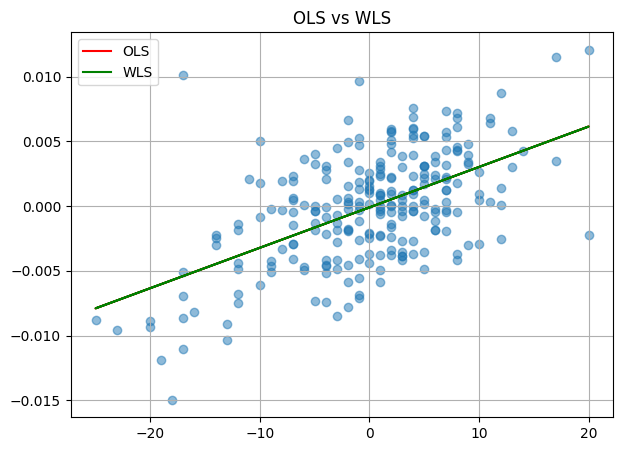

     [Diag 2] R2_OLS=0.3143 | R2_WLS=0.3141 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=10.6487 | t_EIV=10.6487 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

  📊 BRENT → DXY

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -9.002877647182875e-05
Beta: -0.03133224814702724

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.21207
→ NO se rechaza H0: varianza constante



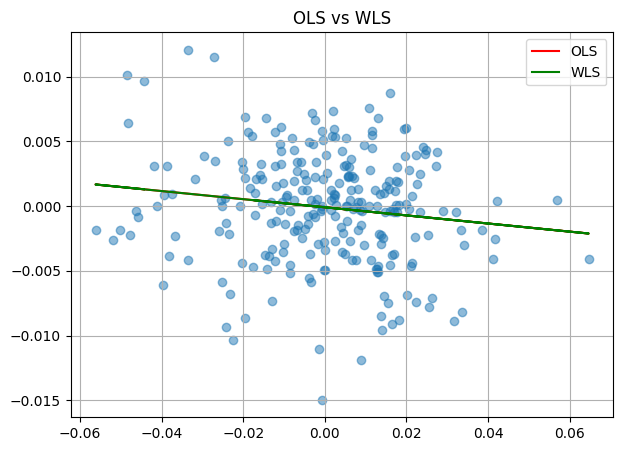

     [Diag 2] R2_OLS=0.0192 | R2_WLS=0.0191 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=-2.2321 | t_EIV=-1.2402 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] 🟡 SEÑAL DÉBIL (mismo signo pero no ambas sig.)

  📊 HYG → DXY

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -1.2712152135277801e-05
Beta: -0.3855470932809978

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.29065
→ NO se rechaza H0: varianza constante



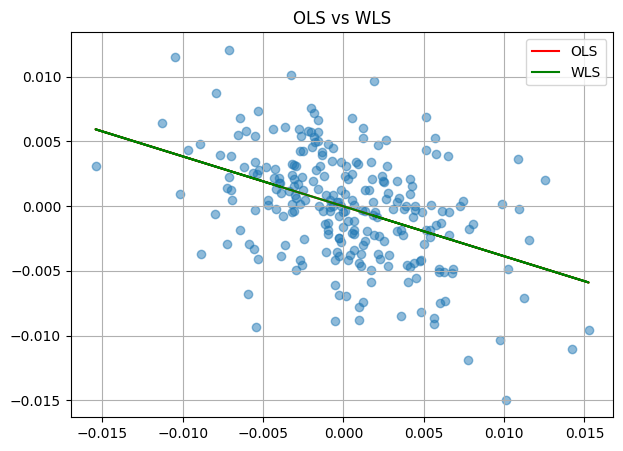

     [Diag 2] R2_OLS=0.1933 | R2_WLS=0.1931 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=-7.7076 | t_EIV=-0.0925 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

  📊 VIX → DXY

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -6.188008716437166e-05
Beta: 0.012844671143317896

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.89201
→ NO se rechaza H0: varianza constante



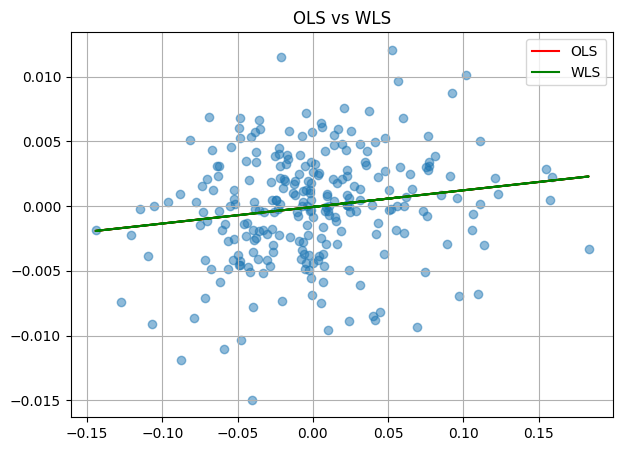

     [Diag 2] R2_OLS=0.0314 | R2_WLS=0.0312 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=2.881 | t_EIV=2.7888 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] 🟡 SEÑAL DÉBIL (mismo signo pero no ambas sig.)

  📊 EXP_INF_USA5 → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.0005992230552086781
Beta: -0.0001963290787131408

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.13272
→ NO se rechaza H0: varianza constante



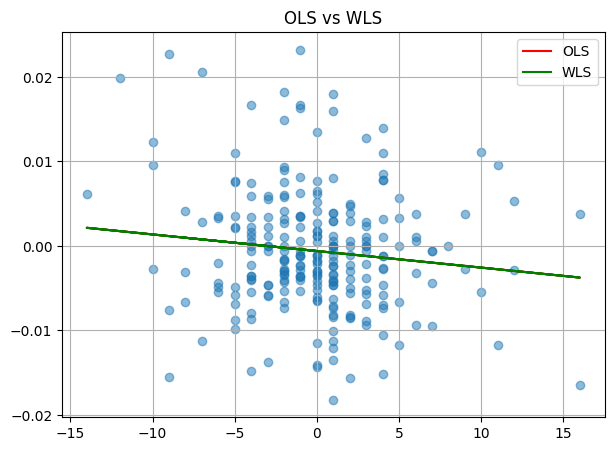

     [Diag 2] R2_OLS=0.0194 | R2_WLS=0.019 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=-2.2138 | t_EIV=-2.2138 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 TIPS5 → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.0005773777892341197
Beta: 0.000131437650321088

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.27707
→ NO se rechaza H0: varianza constante



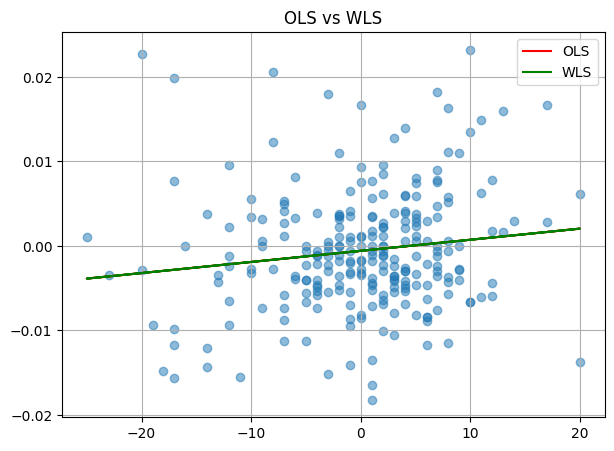

     [Diag 2] R2_OLS=0.0217 | R2_WLS=0.0216 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=2.3399 | t_EIV=2.3399 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 BRENT → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.0004982574254529313
Beta: -0.02110287895993831

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.07870
→ NO se rechaza H0: varianza constante



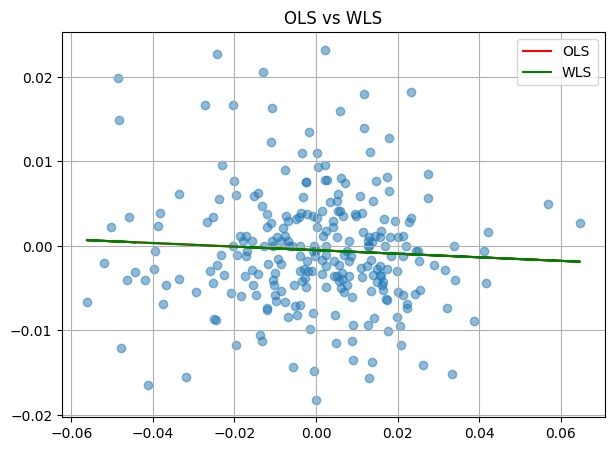

     [Diag 2] R2_OLS=0.0029 | R2_WLS=0.0029 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=-0.867 | t_EIV=-0.6214 | ❌ No significativo en ambos
     [Diag 4] ⚠️  FACTOR INESTABLE (signo cambia entre mitades)

  📊 HYG → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.0004172077982568651
Beta: -0.6563455144443959

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.00494
→ Se RECHAZA H0: hay heterocedasticidad (varianza NO constante)



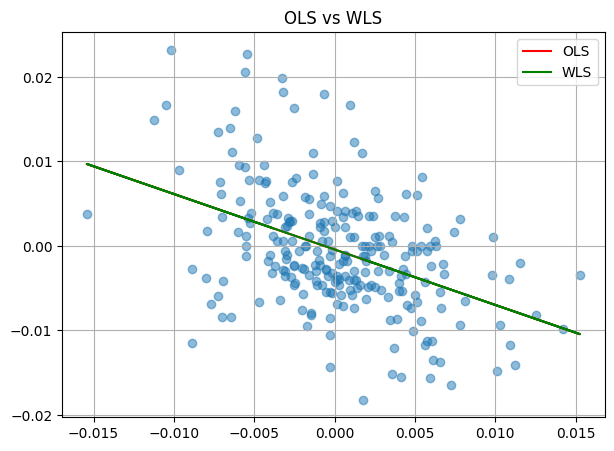

     [Diag 2] R2_OLS=0.2063 | R2_WLS=0.206 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=-8.0295 | t_EIV=-0.0562 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

  📊 VIX → USDMXN

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: -0.00044919001367833
Beta: 0.06666710857695049

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.07118
→ NO se rechaza H0: varianza constante



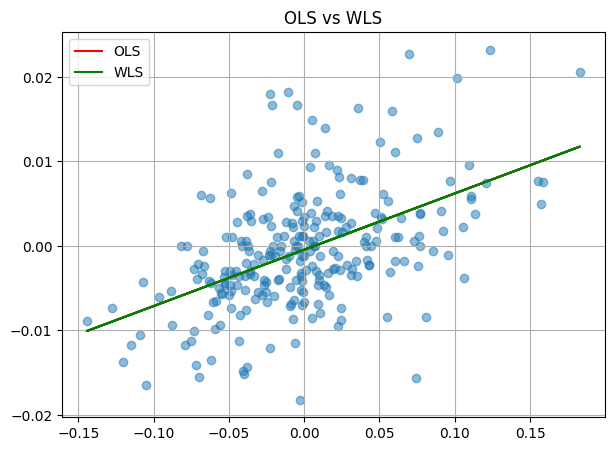

     [Diag 2] R2_OLS=0.2443 | R2_WLS=0.2441 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=9.1154 | t_EIV=5.8233 | ✅ Factor genuino (EIV no cambia conclusión)
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

══════════════════════════════════════════════════════════════════════
                   RESUMEN FINAL — RECOMENDACIONES                    
══════════════════════════════════════════════════════════════════════
  TIPS5           → DXY        | Puntaje: 5/6 | 🟢 USAR
  VIX             → USDMXN     | Puntaje: 5/6 | 🟢 USAR
  HYG             → DXY        | Puntaje: 4/6 | 🟢 USAR
  HYG             → USDMXN     | Puntaje: 4/6 | 🟢 USAR
  VIX             → DXY        | Puntaje: 3/6 | 🟡 CON CAUTELA
  EXP_INF_USA5    → USDMXN     | Puntaje: 3/6 | 🟡 CON CAUTELA
  TIPS5           → USDMXN     | Puntaje: 3/6 | 🟡 CON CAUTELA
  EXP_INF_USA5    → DXY        | Puntaje: 2/6 | 🟡 CON CAUTELA
  BRENT           → DXY        | Puntaje: 2/6 | 🟡 CON CAUTELA
  BRENT     

In [ ]:
# ── EN TU NOTEBOOK, EL FLUJO CORRECTO ES ─────────────────────

from_date = '2023-01-01'
to_date   = '2023-12-31'

benchmarks_x  = ['EXP_INF_USA5', 'TIPS5', 'BRENT', 'HYG', 'VIX']
securities_y  = ['DXY', 'USDMXN']

# ── PASO 0-4: Diagnóstico completo Kan-Zhang ──────────────────
df_kz, usar, cautela, descartar = rrm.pipeline_kan_zhang(
    benchmarks_x, securities_y,
    from_date, to_date,
    significance=0.05,
    umbral_corr_factores=0.7,
    min_obs=20
)

# ── SOLO CON LOS FACTORES QUE PASARON EL FILTRO ──────────────
benchmarks_filtrados = usar + cautela  # excluyes 'descartar'

r2_2023 = rrm.buscar_mejor_r2(
    x=benchmarks_filtrados,
    y=securities_y,
    start_date=from_date,
    end_date=to_date,
    min_obs=20,
    min_corr=0
)

# ── LUEGO TU ANÁLISIS HABITUAL ────────────────────────────────
rrm.imprimir_resumen_frecuencias(r2_2023)
df_temp = rrm.analizar_temporalidad_todos_los_pares(r2_2023)
rrm.imprimir_mejores_periodos(df_temp)

In [16]:
# ── Una vez que tienes los factores del pipeline Kan-Zhang ─────

# Factores que pasaron (de tu output anterior):
usar    = ['VIX']
cautela = ['EXP_INF_USA5', 'BRENT', 'HYG']
benchmarks_filtrados = usar + cautela

securities = ['DXY', 'USDMXN']

# ── Betas Vasicek usando el 28-feb como quiebre ────────────────
df_vasicek = rrm.vasicek_pipeline(
    benchmarks_recomendados = benchmarks_filtrados,
    securities_y            = securities,
    fecha_quiebre           = '2026-02-28',
    ventana_prior_dias      = 40,    # ~2 meses de prior
    from_date_post          = '2026-02-28',
    to_date_post            = '2026-04-17',
    s2_prior_difusa         = 1.0    # prior difusa si hay pocos datos pre
)

print(df_vasicek)


██████████████████████████████████████████████████████████████████████
              PIPELINE VASICEK (1973) — BETAS BAYESIANAS              
                         Quiebre: 2026-02-28                          
                    Prior: 2026-01-19 → 2026-02-28                    
                    Post:  2026-02-28 → 2026-04-17                    
██████████████████████████████████████████████████████████████████████

────────────────────────────────────────────────────────────
  PAR: VIX → DXY
────────────────────────────────────────────────────────────

  [PRIOR — régimen pre-quiebre]

  Prior estimada de 2026-01-19 a 2026-02-28
  b' = -0.000589 | s'²_b = 0.00007810 | R² = 0.0002 | N = 30
  ⚠️  R²_prior bajo (0.0002) → prior poco informativa
     s'²_prior ajustada a 0.00023430 (x3)

  [MUESTRA — período de análisis]
  b_OLS = 0.025568 | s²_b = 0.00004944 | R² = 0.2860 | N = 35

  [VASICEK — combinación Bayesiana]

═══════════════════════════════════════════════════════════════

In [17]:
# Las fechas clave que ya identificaste
fechas_candidatas = ['2026-02-20', '2026-02-28', '2026-04-08']

benchmarks = ['EXP_INF_USA5', 'TIPS5', 'BRENT', 'VIX', 'HYG']
activos    = ['DXY', 'USDMXN']

df_chow = rrm.chow_multiplos_factores(
    benchmarks, activos,
    fechas_candidatas,
    from_date='2026-01-02',
    to_date='2026-04-17',
    significance=0.05
)


────────────────────────────────────────────────────────────
CHOW TEST: EXP_INF_USA5 → DXY
Fecha de quiebre: 2026-02-20
────────────────────────────────────────────────────────────
  F = 1.8302 | p-value = 0.1679
  Beta PRE:  -0.0000  (r=-0.0183, R2=0.0003)
  Beta POST: 0.0006  (r=0.5524, R2=0.3051)
  ✅ Sin evidencia de cambio estructural

────────────────────────────────────────────────────────────
CHOW TEST: EXP_INF_USA5 → DXY
Fecha de quiebre: 2026-02-28
────────────────────────────────────────────────────────────
  F = 2.2618 | p-value = 0.1117
  Beta PRE:  0.0000  (r=0.0025, R2=0.0000)
  Beta POST: 0.0006  (r=0.5694, R2=0.3243)
  ✅ Sin evidencia de cambio estructural

────────────────────────────────────────────────────────────
CHOW TEST: EXP_INF_USA5 → DXY
Fecha de quiebre: 2026-04-08
────────────────────────────────────────────────────────────
  F = 0.3192 | p-value = 0.7278
  Beta PRE:  0.0005  (r=0.3760, R2=0.1413)
  Beta POST: 0.0004  (r=0.5472, R2=0.2994)
  ✅ Sin evidencia 

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/BBVA.csv')
# Función para convertir los valores
def parse_volume(valor):
    if pd.isna(valor):
        return None
    
    valor = str(valor).strip().replace(',', '.')
    
    if 'M' in valor:
        return float(valor.replace('M', '')) * 1_000_000
    elif 'K' in valor:
        return float(valor.replace('K', '')) * 1_000
    else:
        return float(valor)

# Aplicar la transformación
df['Volumen'] = df['Vol.'].apply(parse_volume)

rrm.cargar_archivo(df, 'VolumenBBVA')


Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/VolumenBBVA.csv


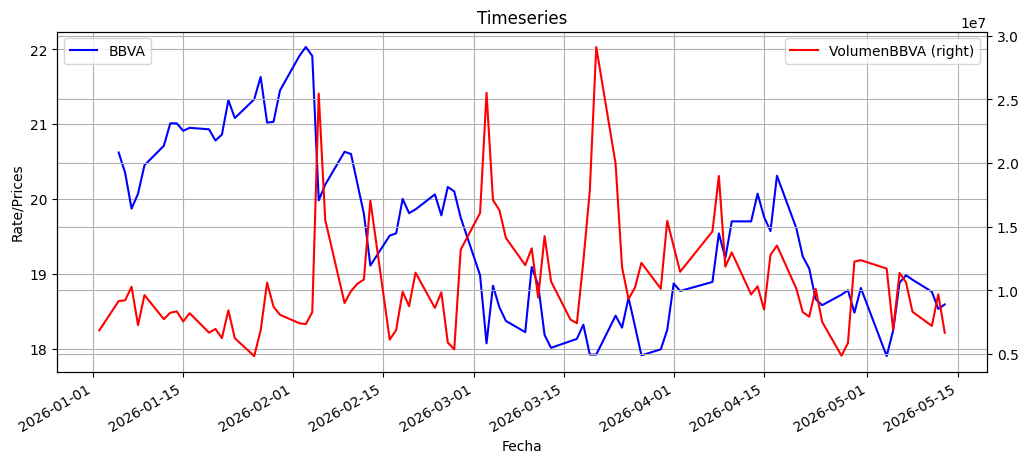

In [27]:

rrm.plot_two_timeseries('BBVA', 'VolumenBBVA', 'Cierre', 'Volumen', from_date='2026-01-01')

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/GFNORTEO.csv')
# Función para convertir los valores
def parse_volume(valor):
    if pd.isna(valor):
        return None
    
    valor = str(valor).strip().replace(',', '.')
    
    if 'M' in valor:
        return float(valor.replace('M', '')) * 1_000_000
    elif 'K' in valor:
        return float(valor.replace('K', '')) * 1_000
    else:
        return float(valor)

# Aplicar la transformación
df['Volumen'] = df['Vol.'].apply(parse_volume)

rrm.cargar_archivo(df, 'VolumenGFNORTEO')


Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/VolumenGFNORTEO.csv


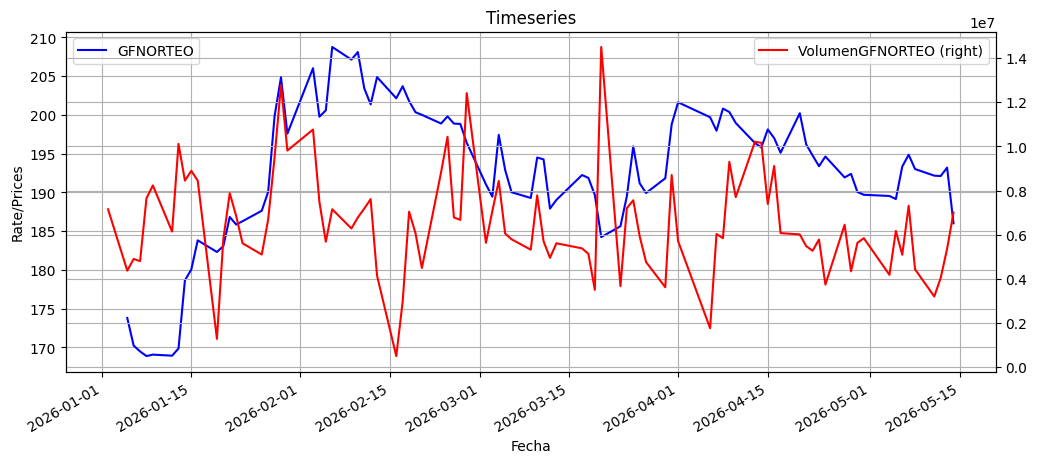

In [43]:
rrm.plot_two_timeseries('GFNORTEO', 'VolumenGFNORTEO', 'Cierre', 'Volumen', from_date='2026-01-01')


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/GCARSOA1.csv')
# Función para convertir los valores
def parse_volume(valor):
    if pd.isna(valor):
        return None
    
    valor = str(valor).strip().replace(',', '.')
    
    if 'M' in valor:
        return float(valor.replace('M', '')) * 1_000_000
    elif 'K' in valor:
        return float(valor.replace('K', '')) * 1_000
    else:
        return float(valor)

# Aplicar la transformación
df['Volumen'] = df['Vol.'].apply(parse_volume)

rrm.cargar_archivo(df, 'VolumenGCARSO')

Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/VolumenGCARSO.csv


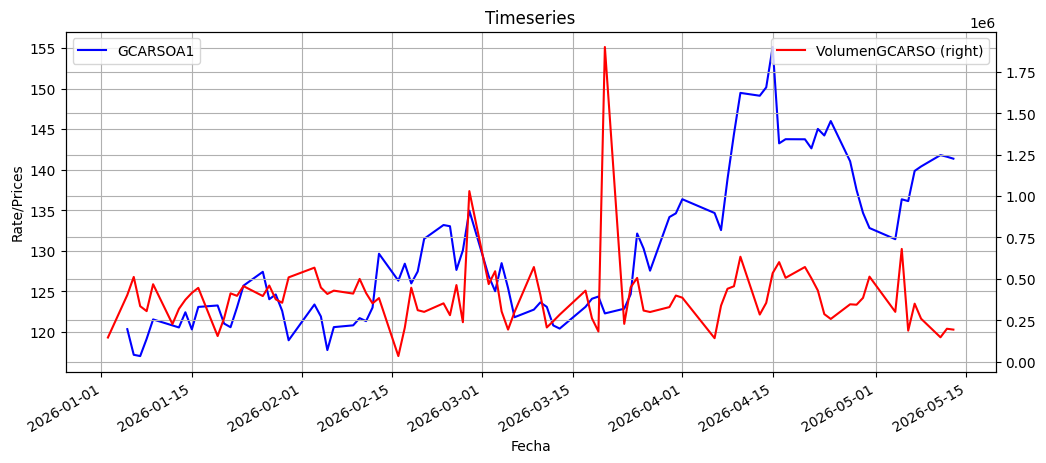

In [33]:
rrm.plot_two_timeseries('GCARSOA1', 'VolumenGCARSO', 'Cierre', 'Volumen', from_date='2026-01-01')

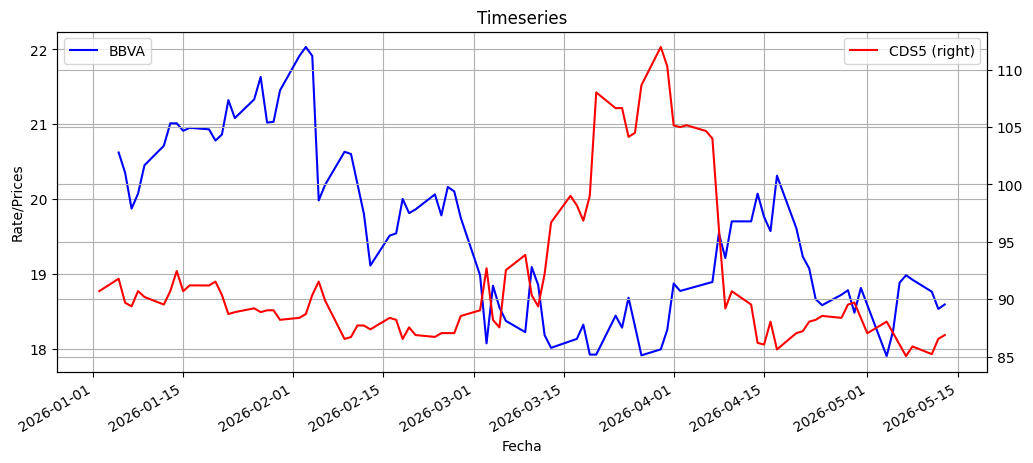

In [34]:
rrm.plot_two_timeseries('BBVA', 'CDS5', 'Cierre', 'Cierre', from_date='2026-01-01')

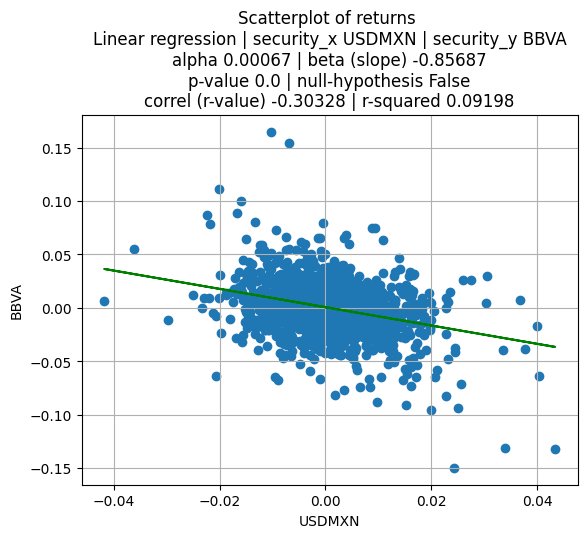

In [53]:
mod = rrm.model('USDMXN', 'BBVA', model_type='macro')
mod.synchronise_timeseries()
mod.compute_linear_reg()
mod.plot_linear_reg()

In [104]:
import importlib
import macro_analysis.automated_tools as at
importlib.reload(at)

<module 'macro_analysis.automated_tools' from '/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py'>

/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:1616: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  tr_smooth = data["TR"].rolling(window=adx_p).sum()


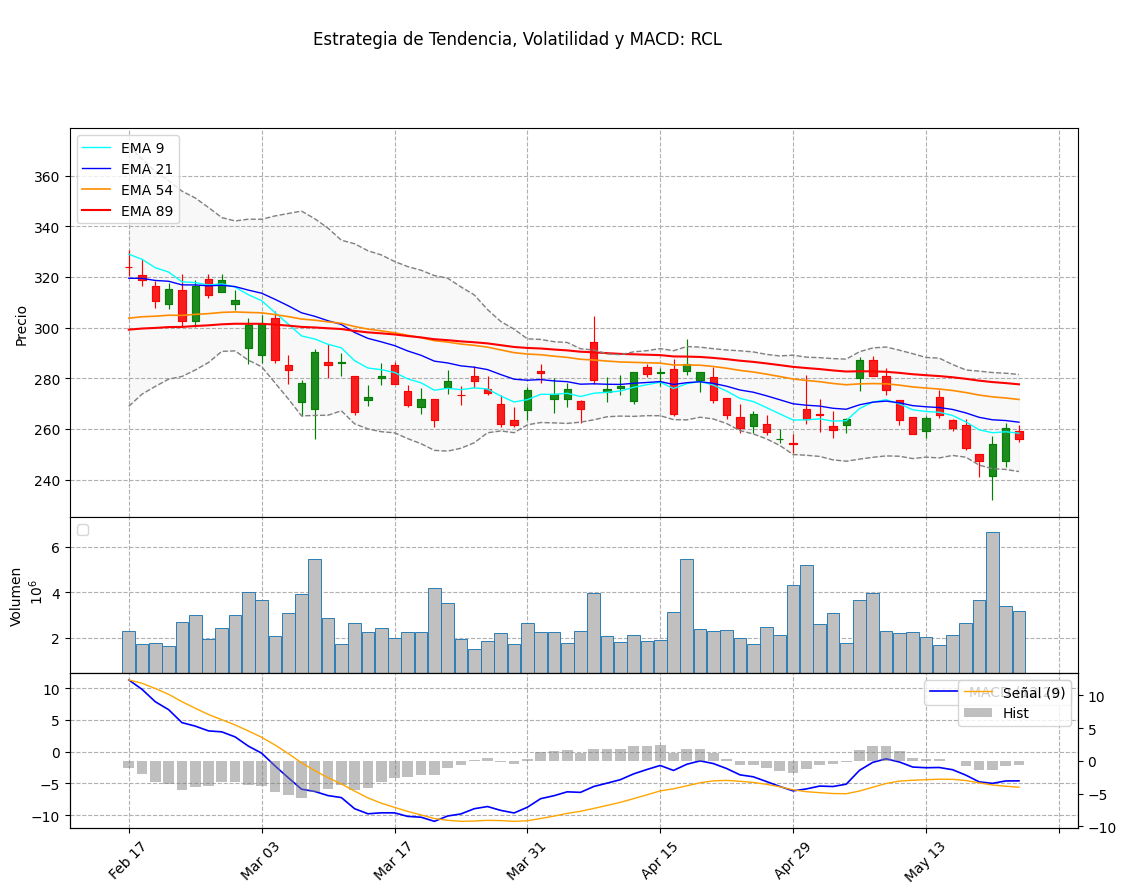

In [ ]:
# DEJAR PENDIENTE
# Paso A: Descargar datos puros de Yahoo Finance
datos_bbva = yf.download("RCL", start="2025-05-01", auto_adjust=False, progress=False)
if isinstance(datos_bbva.columns, pd.MultiIndex):
    datos_bbva.columns = datos_bbva.columns.droplevel(1)

# Paso B: Aplicar la función de cálculo (Genera medias, Bollinger, Estocástico y MACD)
df_bbva_procesado = at.calcular_indicadores_avanzados(datos_bbva)

# Paso C: Graficar usando el sistema de EMAs rápidas + Bandas + MACD
at.plot_trend_and_macd(df_bbva_procesado, ticker="RCL", usar_emas=True)


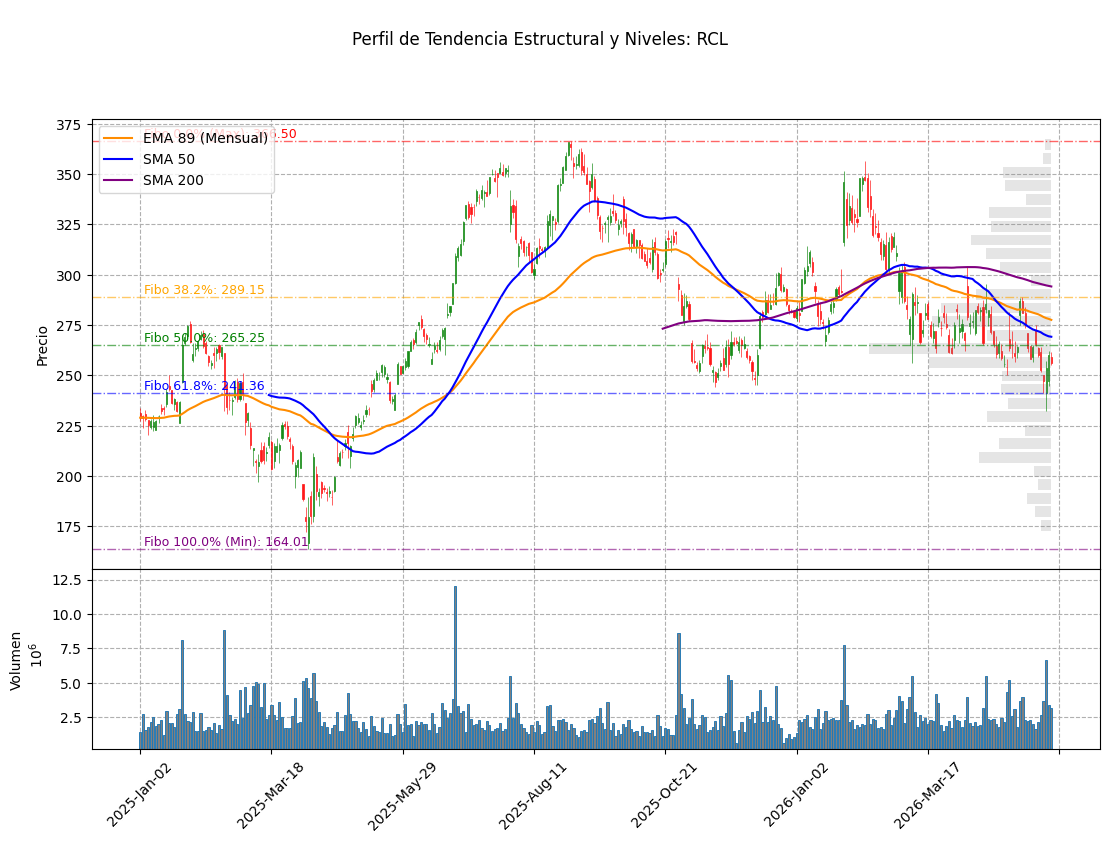

In [112]:
# Llamada para ver el gráfico estructural de BBVA
at.plot_advanced_trend_profile(
    ticker="RCL", 
    from_date="2025-01-01"
)

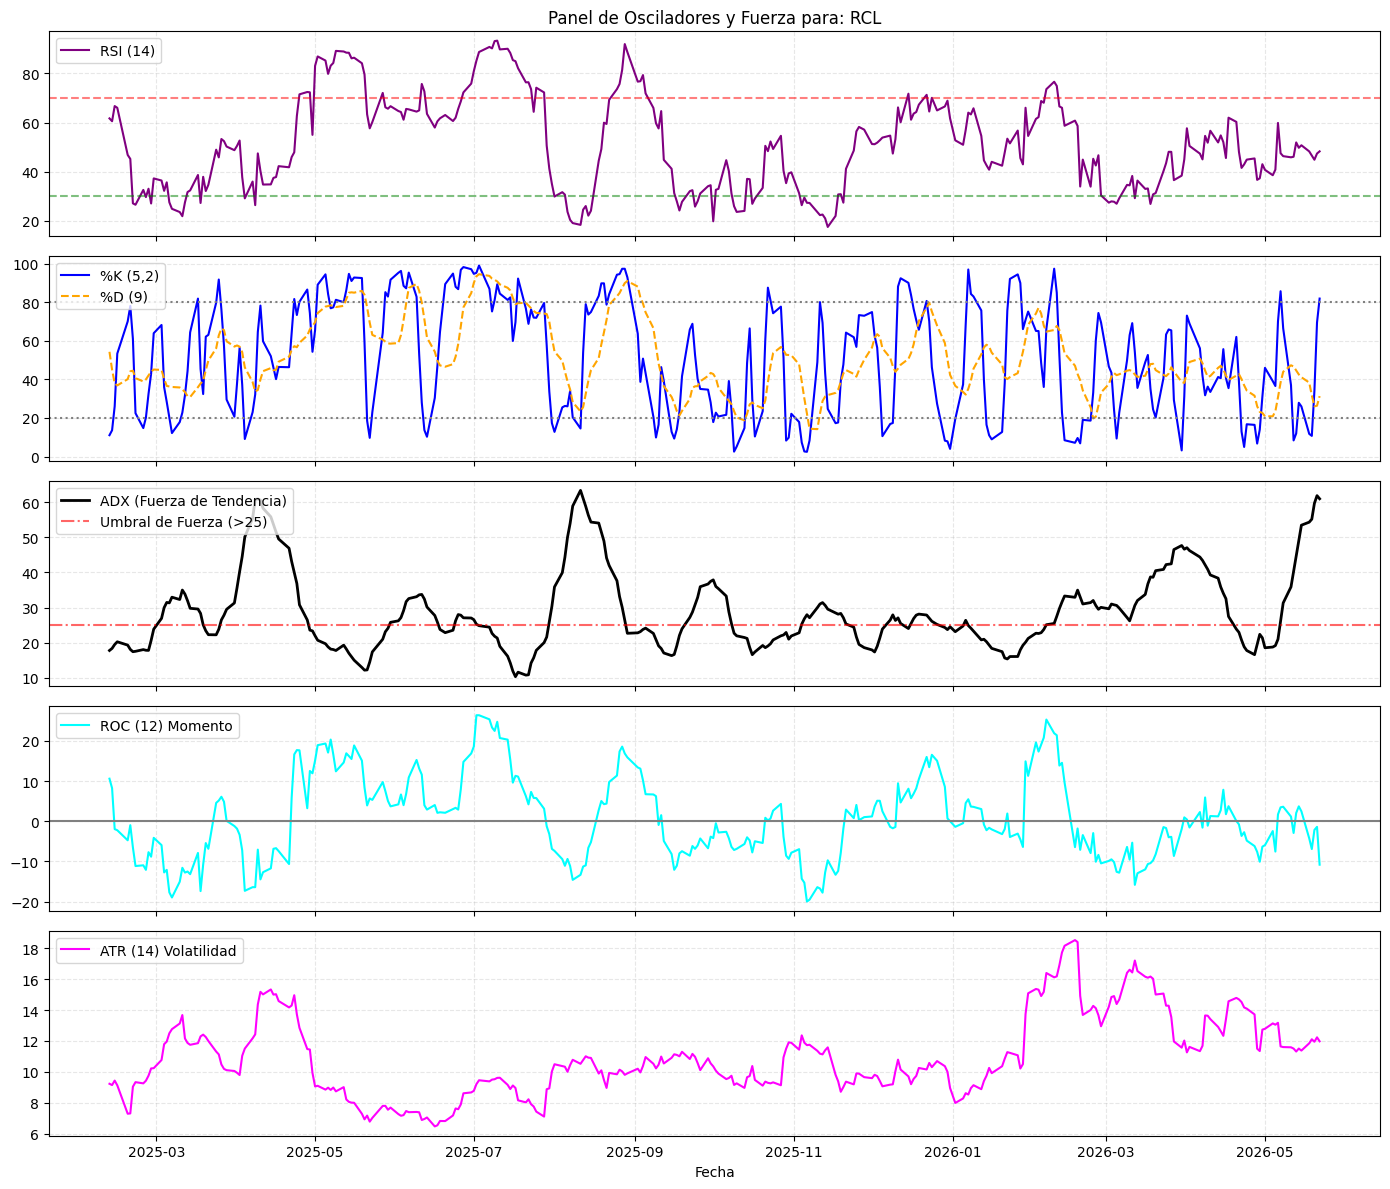

In [114]:
# Llamada para evaluar RSI, Estocástico personalizado, ADX, ROC y ATR de BBVA
at.plot_advanced_oscillators(
    ticker="RCL", 
    from_date="2025-01-01",
    est_k=5,  # Periodo K
    est_d=9,  # Periodo D de la señal
    est_s=2   # Suavizado inicial K
)


In [90]:
df = at.detect_volume_confluence_bombs(
    'XLY',
    from_date="2025-06-01",
    to_date='2026-04-01')# '2026-03-20'
print(df)


=== ANÁLISIS DE CONFLUENCIA PARA XLY ===
Periodo analizado: 2025-06-02 al 2026-03-31

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para XLY.
    La última confluencia registrada fue el: 2026-02-06 (Score: 2.72)
Price             Open        High         Low       Close    Volume  \
Date                                                                   
2025-06-02  106.595001  107.165001  105.279999  107.150002   8783800   
2025-06-03  107.245003  108.614998  107.220001  107.720001   7855400   
2025-06-04  107.809998  107.870003  106.650002  107.434998   7581000   
2025-06-05  107.160004  107.714996  103.855003  104.724998  12096600   
2025-06-06  106.239998  106.584999  105.720001  106.084999   9948800   
...                ...         ...         ...         ...       ...   
2026-03-25  111.160004  111.910004  110.099998  110.730003   9412900   
2026-03-26  110.050003  110.900002  108.739998  108.830002   7981000   
2026-03-27  108.309998  108.309998  105.44

In [64]:
# Universo de 52 activos bajo los límites de precio solicitados
activos_potenciales = [
    # --- Bolsa Mexicana de Valores (BMV) < $400 MXN ---
    "CEMEXCPO.MX", "ALSEA.MX", "GFINBURO.MX", "AGUAS.MX", "BIMBOA.MX", 
    "ORBIA.MX", "GENTERA.MX", "CUERVO.MX", "OMAB.MX", "PINFRA.MX",
    "PENOLES.MX", "GCARSOA1.MX", "LIVEPOLC.MX", "SORIANAB.MX", "TLEVISACPO.MX",
    "AZTECAAL.MX", "LABB.MX", "CHDRAUIB.MX", "ALFAA.MX", "VESTA.MX",
    "GNP.MX", "MEGACPO.MX", "IENOVA.MX", "GCC.MX", "FIBRAPL14.MX", "FUNO11.MX",
    
    # --- Mercado Estadounidense (US) < $20 USD ---
    "F", "NIO", "PLTR", "AAL", "SOFI", "PFE", "LCID", "SNAP", "HOOD", 
    "GRWG", "PBR", "BAC", "CLOV", "PLUG", "DKNG", "BABA", "XPEV", "OPEN",
    "RUN", "FUBOTV", "TLRY", "RBLX", "RIG", "NKLA", "BMY", "KVUE"
]

# Ejecución del rastreador masivo
df_oportunidades = at.scan_market_for_bombs(
    activos_potenciales, dias_atras=3, vol_profile_bins=50
)

# Visualizar el DataFrame final con los nominados
print("\n=== TABLA DE OPORTUNIDADES NOMINADAS ===")
print(df_oportunidades)


🔍 Iniciando escaneo de 52 activos en busca de confluencias institucionales...


=== ANÁLISIS DE CONFLUENCIA PARA CEMEXCPO.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para CEMEXCPO.MX.
    La última confluencia registrada fue el: 2025-09-19 (Score: 1.19)

=== ANÁLISIS DE CONFLUENCIA PARA ALSEA.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para ALSEA.MX.
    La última confluencia registrada fue el: 2026-01-22 (Score: 1.73)

=== ANÁLISIS DE CONFLUENCIA PARA GFINBURO.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para GFINBURO.MX.
    La última confluencia registrada fue el: 2026-05-07 (Score: 1.33)



1 Failed download:
['AGUAS.MX']: YFTzMissingError('possibly delisted; no timezone found')


[-] No se encontraron datos para el ticker AGUAS.MX

=== ANÁLISIS DE CONFLUENCIA PARA BIMBOA.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para BIMBOA.MX.
    La última confluencia registrada fue el: 2026-04-30 (Score: 3.17)

=== ANÁLISIS DE CONFLUENCIA PARA ORBIA.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para ORBIA.MX.
    La última confluencia registrada fue el: 2026-03-20 (Score: 1.57)

=== ANÁLISIS DE CONFLUENCIA PARA GENTERA.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para GENTERA.MX.
    La última confluencia registrada fue el: 2026-04-17 (Score: 1.17)

=== ANÁLISIS DE CONFLUENCIA PARA CUERVO.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para CUERVO.MX.
    La última conf


1 Failed download:
['PENOLES.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-01-01 -> 2026-05-24)')


[-] No se encontraron datos para el ticker PENOLES.MX

=== ANÁLISIS DE CONFLUENCIA PARA GCARSOA1.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para GCARSOA1.MX.
    La última confluencia registrada fue el: 2026-03-20 (Score: 3.48)


...

[-] No se encontraron datos para el ticker IENOVA.MX

=== ANÁLISIS DE CONFLUENCIA PARA GCC.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para GCC.MX.
    La última confluencia registrada fue el: 2026-05-04 (Score: 1.7)

=== ANÁLISIS DE CONFLUENCIA PARA FIBRAPL14.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para FIBRAPL14.MX.
    La última confluencia registrada fue el: 2025-09-17 (Score: 1.45)

=== ANÁLISIS DE CONFLUENCIA PARA FUNO11.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para FUNO11.MX.
    La última confluencia registrada fue el: 2025-09-30 (Score: 1.73)

=== ANÁLISIS DE CONFLUENCIA PARA F ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para F.
    La última confluencia registra


1 Failed download:
['FUBOTV']: YFTzMissingError('possibly delisted; no timezone found')


[-] No se encontraron datos para el ticker FUBOTV

=== ANÁLISIS DE CONFLUENCIA PARA TLRY ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para TLRY.
    La última confluencia registrada fue el: 2026-04-23 (Score: 3.49)

=== ANÁLISIS DE CONFLUENCIA PARA RBLX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para RBLX.
    La última confluencia registrada fue el: 2026-05-01 (Score: 1.53)

=== ANÁLISIS DE CONFLUENCIA PARA RIG ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para RIG.
    La última confluencia registrada fue el: 2026-04-27 (Score: 1.26)



1 Failed download:
['NKLA']: YFTzMissingError('possibly delisted; no timezone found')


[-] No se encontraron datos para el ticker NKLA

=== ANÁLISIS DE CONFLUENCIA PARA BMY ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para BMY.
    La última confluencia registrada fue el: 2026-03-20 (Score: 2.65)

=== ANÁLISIS DE CONFLUENCIA PARA KVUE ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para KVUE.
    La última confluencia registrada fue el: 2026-02-05 (Score: 1.49)

🎉 [PROCESO COMPLETADO] Escaneo finalizado. Se encontraron 1 señales válidas.

=== TABLA DE OPORTUNIDADES NOMINADAS ===
  Ticker Fecha_Señal  Precio_Cierre  Vol_ZScore  Bomba_Score
0    NIO  2026-05-21            5.6        3.42         2.38


In [69]:
# Array extendido con 100 nuevos activos potenciales
nuevos_activos_potenciales = [
    # =========================================================================
    # --- BOLSA MEXICANA DE VALORES (BMV) < $400 MXN (50 Activos Nuevos) ---
    # =========================================================================
    "GFNORTEO.MX", "WALMEX.MX", "GMEXICOB.MX", "GRUMAB.MX", "GAPB.MX",
    "ASURB.MX", "AC.MX", "KOFUBL.MX", "FEMSAUBD.MX", "ALPEKA.MX",
    "BOLSAA.MX", "CYDSASA.MX", "FRAGUAB.MX", "GISSAO.MX", "GOUT.MX",
    "HERDEZ.MX", "HOMEX.MX", "IDEALB1.MX", "KUOB.MX", "LACOMERC.MX",
    "MFRISCOA1.MX", "PASAB.MX", "POSADASB.MX", "SANMEXB.MX", "TEAKCPO.MX",
    "URBI.MX", "VALUEGFO.MX", "VINTE.MX", "VOLARA.MX", "ARA.MX",
    "AUTLANB.MX", "CABLECPO.MX", "CMOCTEZ.MX", "COCACOLA.MX", "DISH.MX",
    "ELEKTRA.MX", "FINAMEXB.MX", "GPH1.MX", "HUAMUX.MX", "MACOCOA.MX",
    "MEDICAB.MX", "MONEXB.MX", "OHLMEX.MX", "PROCORB.MX", "Q.MX",
    "RASSINIBA.MX", "SIMECB.MX", "TAVOCPO.MX", "VISTA.MX", "VITROA.MX",

    # =========================================================================
    # --- MERCADO ESTADOUNIDENSE (US) < $20 USD (50 Activos Nuevos) ---
    # =========================================================================
    "PTON", "AAL", "CCL", "NCLH", "RCL", "SAVE", "JBLU", "TAL", 
    "GOTU", "EDU", "IQ", "HUYA", "DOYU", "BITF", "HUT", "MARA", 
    "RIOT", "CAN", "MSTR", "COIN", "WISH", "XPEV", "LI", "NIO", 
    "BYDDY", "Fisker", "WKHS", "RIDE", "GOEV", "HYLN", "NKLA", "QS", 
    "SLDP", "MVST", "FREY", "ENVX", "RUN", "NOVA", "CHPT", "BLNK", 
    "EVGO", "BE", "FCEL", "PLUG", "AMRC", "CLNE", "GEVO", "PEI", 
    "CENX", "X"
]

# Ejecución del rastreador masivo
df_oportunidades = at.scan_market_for_bombs(
    nuevos_activos_potenciales, dias_atras=3, vol_profile_bins=50
)

# Visualizar el DataFrame final con los nominados
print("\n=== TABLA DE OPORTUNIDADES NOMINADAS ===")
print(df_oportunidades)


🔍 Iniciando escaneo de 100 activos en busca de confluencias institucionales...


=== ANÁLISIS DE CONFLUENCIA PARA GFNORTEO.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para GFNORTEO.MX.
    La última confluencia registrada fue el: 2025-12-19 (Score: 3.46)

=== ANÁLISIS DE CONFLUENCIA PARA WALMEX.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para WALMEX.MX.
    La última confluencia registrada fue el: 2026-03-20 (Score: 3.08)

=== ANÁLISIS DE CONFLUENCIA PARA GMEXICOB.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para GMEXICOB.MX.
    La última confluencia registrada fue el: 2025-10-06 (Score: 0.37)

=== ANÁLISIS DE CONFLUENCIA PARA GRUMAB.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 día


1 Failed download:
['CYDSASA.MX']: YFTzMissingError('possibly delisted; no timezone found')


[-] No se encontraron datos para el ticker CYDSASA.MX

=== ANÁLISIS DE CONFLUENCIA PARA FRAGUAB.MX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para FRAGUAB.MX.
    La última confluencia registrada fue el: 2026-05-12 (Score: 3.98)



1 Failed download:
['GISSAO.MX']: YFTzMissingError('possibly delisted; no timezone found')


[-] No se encontraron datos para el ticker GISSAO.MX


...

[-] No se encontraron datos para el ticker NOVA

=== ANÁLISIS DE CONFLUENCIA PARA CHPT ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para CHPT.
    La última confluencia registrada fue el: 2026-05-18 (Score: 2.01)

=== ANÁLISIS DE CONFLUENCIA PARA BLNK ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para BLNK.
    La última confluencia registrada fue el: 2026-05-11 (Score: 3.09)

=== ANÁLISIS DE CONFLUENCIA PARA EVGO ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para EVGO.
    La última confluencia registrada fue el: 2026-05-06 (Score: 2.37)

=== ANÁLISIS DE CONFLUENCIA PARA BE ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para BE.
    La última confluencia registrada fue el: 2025-11-21 (Score: 0.


1 Failed download:
['PEI']: YFTzMissingError('possibly delisted; no timezone found')


[-] No se encontraron datos para el ticker PEI

=== ANÁLISIS DE CONFLUENCIA PARA CENX ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para CENX.
    La última confluencia registrada fue el: 2026-03-30 (Score: 0.63)



1 Failed download:
['X']: YFTzMissingError('possibly delisted; no timezone found')


[-] No se encontraron datos para el ticker X

🎉 [PROCESO COMPLETADO] Escaneo finalizado. Se encontraron 3 señales válidas.

=== TABLA DE OPORTUNIDADES NOMINADAS ===
      Ticker Fecha_Señal  Precio_Cierre  Vol_ZScore  Bomba_Score
0        NIO  2026-05-21           5.60        3.42         2.38
1        RCL  2026-05-20         253.89        2.85         1.78
2  VITROA.MX  2026-05-20           5.61        2.50         0.21


In [81]:
# Array balanceado con 100 nuevos activos entre el rango de precios solicitado ($800 MXN / ~$45 USD)
mexicanas_nuevas = [
    "AMX/B.MX", "FMX.MX", "ASR.MX", "PAC.MX", "BBVA.MX", "SAN.MX", "NEMAKA.MX",
    "BAFARB.MX", "ACTINVRB.MX", "ALTERNA.MX", "AGUAB.MX", "CULTIBAR.MX", "FHIPO14.MX",
    "FINN13.MX", "FIHO12.MX", "FMTY14.MX", "FIBRATC14.MX", "FCFE18.MX", "FVIA16.MX",
    "GPROFUT.MX", "HCITY.MX", "HOTEL.MX", "KUEHNE.MX", "MONTERR.MX", "POCHTECB.MX",
    "SAREB.MX", "SPORTB.MX", "TMMA.MX", "CONSTRUB.MX", "DINEB.MX", "EDOARDOB.MX",
    "FRISA.MX", "GIGANTE.MX", "HOGARB.MX", "INVEXA.MX", "MINSAB.MX", "RECORDB.MX",
    "SANLUIS.MX", "TEKCHEMB.MX", "UNIFEDA.MX", "ALMAIER.MX", "COLLADO.MX", "FOMENTO.MX",
    "GSANBOR.MX", "LAMOSA.MX", "PAPPEL.MX", "RRECOGN.MX", "SAB.MX", "TRACANA.MX",
    "VALMEXB.MX", "GICSAA.MX", "AEROMEX.MX", "HCP.MX", "BBAJIOO.MX", "CUERVO.MX",
    "CREAL.MX", "GBMO.MX", "GFAMSA.MX", "GNP.MX", "ICA.MX", "JAC.MX", "MAXCOMA.MX",
    "POSADASA.MX", "QUALITAS.MX", "SAN.MX", "TMMB.MX", "TS.MX", "VENCAL.MX",
    "FSHOP13.MX", "FIBRAMQ12.MX", "FIBRAHD15.MX", "FUPREMO.MX", "GCOLLADO.MX", "PUEBLA.MX",
    "COCACOLA.MX", "MCDONALDS.MX", "STARBUCKS.MX", "APPLE.MX", "MICROSOFT.MX", "AMAZON.MX",
    "META.MX", "GOOGL.MX", "NETFLIX.MX", "TESLA.MX", "NVIDIA.MX", "AMD.MX",
    "INTC.MX", "DISNEY.MX", "NIKE.MX", "SBUX.MX", "KO.MX", "PEP.MX",
    "COST.MX", "WMT.MX", "V.MX", "MA.MX", "AXP.MX", "JPM.MX", "GS.MX"
]
americanas_nuevas = [
    "AAPL", "MSFT", "AMZN", "NVDA", "GOOGL", "META", "TSLA", "NFLX", "AMD", "DIS",
    "NKE", "KO", "PEP", "COST", "WMT", "V", "MA", "AXP", "JPM", "GS",
    "MS", "C", "UNH", "CVS", "LLY", "ABBV", "MRK", "JNJ", "TMO", "DHR",
    "GE", "HON", "CAT", "DE", "MMM", "LMT", "BA", "RTX", "UPS", "FDX",
    "XOM", "CVX", "COP", "EOG", "SLB", "HAL", "NEE", "DUK", "SO", "AEP",
    "AMT", "PLD", "CCI", "EQIX", "SPG", "O", "AVGO", "QCOM", "TXN", "MU",
    "LRCX", "KLAC", "AMAT", "NOW", "CRM", "PANW", "FTNT", "CRWD", "DDOG", "NET",
    "SNOW", "TEAM", "WDAY", "ADBE", "ORCL", "IBM", "CSCO", "ACN", "INFY", "WIT",
    "HD", "LOW", "TJX", "NKE", "NVR", "LEN", "DHI", "PHM", "MCD", "CMG",
    "YUM", "DRI", "SBUX", "BKNG", "EXPE", "MAR", "HLT", "RCL", "CCL", "NCLH"
]


# Ejecución del rastreador masivo
df_oportunidades = at.scan_market_for_bombs(
    americanas_nuevas, dias_atras=3, vol_profile_bins=50
)

# Visualizar el DataFrame final con los nominados
print("\n=== TABLA DE OPORTUNIDADES NOMINADAS ===")
print(df_oportunidades)


🔍 Iniciando escaneo de 100 activos en busca de confluencias institucionales...


=== ANÁLISIS DE CONFLUENCIA PARA AAPL ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para AAPL.
    La última confluencia registrada fue el: 2026-04-30 (Score: 1.68)

=== ANÁLISIS DE CONFLUENCIA PARA MSFT ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para MSFT.
    La última confluencia registrada fue el: 2026-04-30 (Score: 2.24)

=== ANÁLISIS DE CONFLUENCIA PARA AMZN ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para AMZN.
    La última confluencia registrada fue el: 2026-02-06 (Score: 2.99)

=== ANÁLISIS DE CONFLUENCIA PARA NVDA ===
Periodo analizado: 2024-01-02 al 2026-05-22

[-] No se detectaron patrones de 'Bomba' activos en los últimos 3 días para NVDA.
    La última confluencia regi

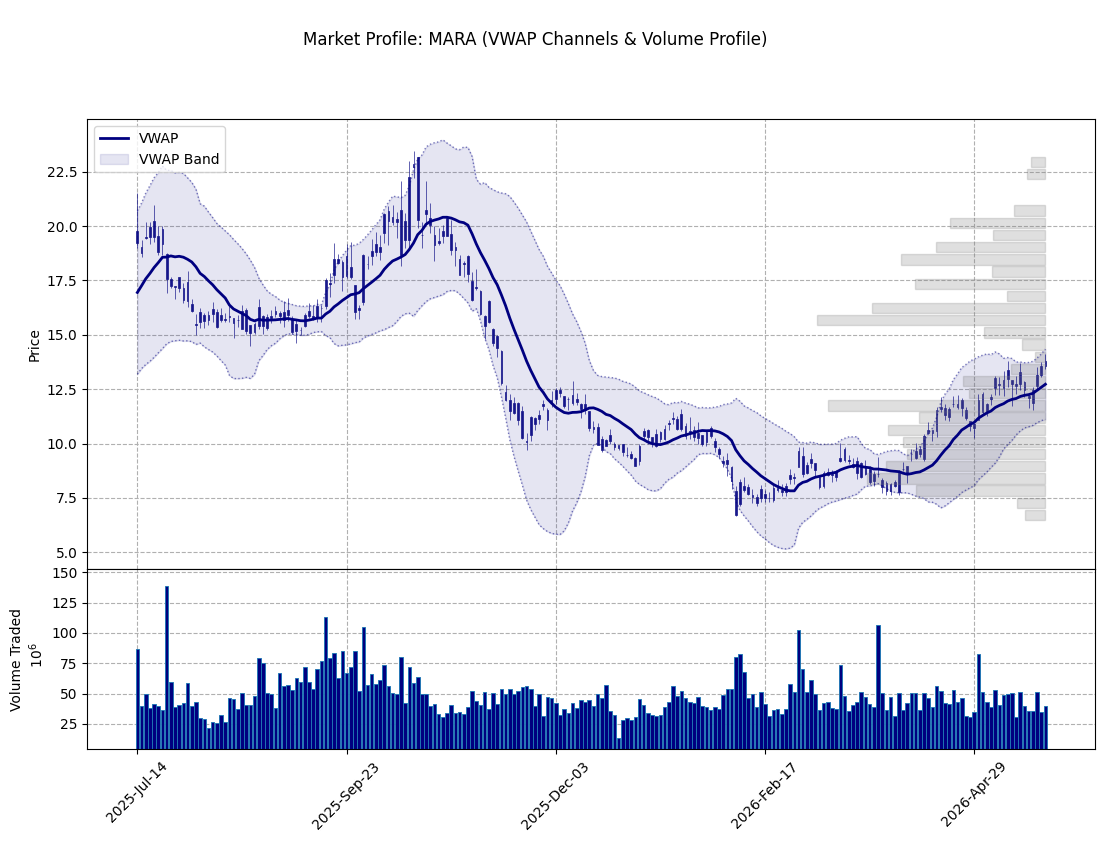

In [92]:
# Ejemplo con Apple, usando tonalidades de azul
df_analisis = at.plot_advanced_market_profile(
    ticker = 'MARA',
    from_date="2025-06-01",
    #to_date='2026-04-01',
    vwap_window=15, 
    price_color="navy"
)



=== REPORTE DE DÍAS CON VOLUMEN ANORMALMENTE ALTO PARA LOW.MX ===
Fecha (Año-Mes-Día)  Volumen Diario  RelVol  Rotación Float (%)                                                                                                                    Razón del Impacto
         2026-05-20             572    2.94                 0.0  Volumen Muy Alto (Foco de Mercado) (X 2.94 del promedio). Caída con Presión / Pánico (Liquidación masiva) | Rotación de Float: 0.0%
         2026-05-06             620    3.39                 0.0  Volumen Muy Alto (Foco de Mercado) (X 3.39 del promedio). Caída con Presión / Pánico (Liquidación masiva) | Rotación de Float: 0.0%
         2026-05-04            2000   12.68                 0.0 Volumen Muy Alto (Foco de Mercado) (X 12.68 del promedio). Caída con Presión / Pánico (Liquidación masiva) | Rotación de Float: 0.0%
         2026-04-30             476    8.24                 0.0  Volumen Muy Alto (Foco de Mercado) (X 8.24 del promedio). Caída con Presión / Pá

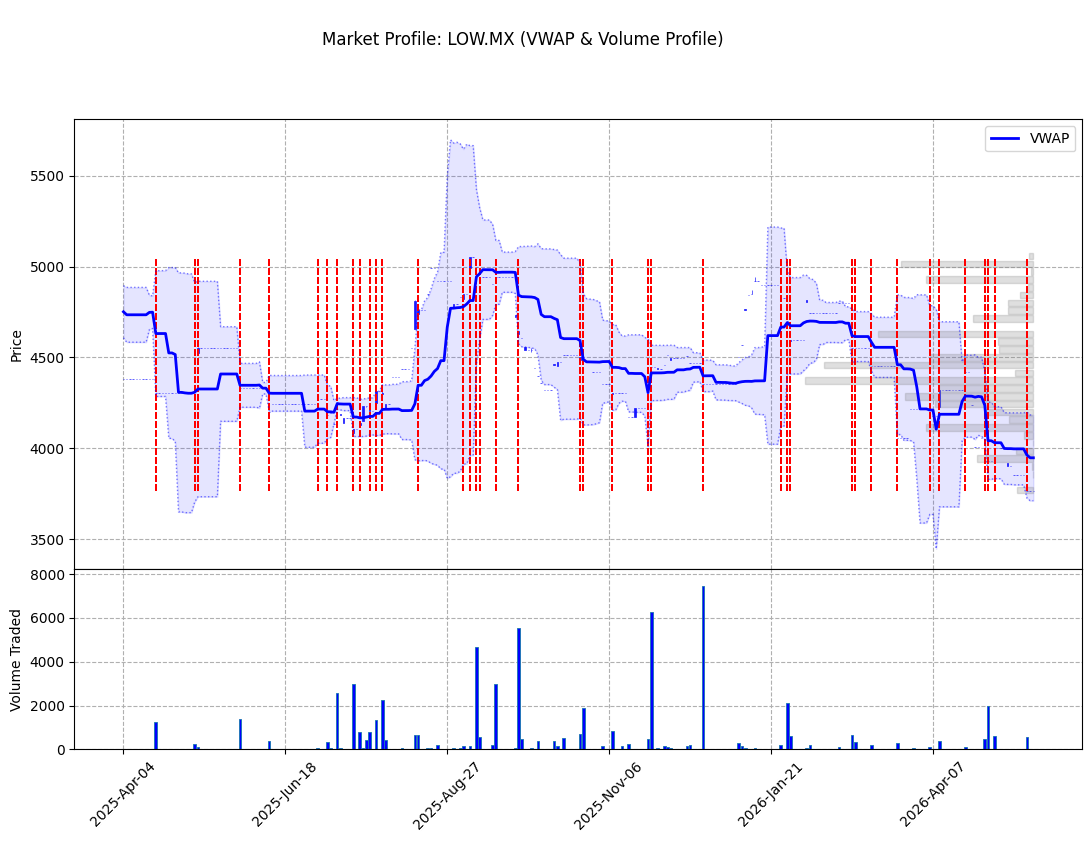

,Fecha (Año-Mes-Día),Volumen Diario,RelVol,Rotación Float (%),Razón del Impacto
0,2026-05-20,572,2.94,0.0,Volumen Muy Alto (Foco de Mercado) (X 2.94 del...
1,2026-05-06,620,3.39,0.0,Volumen Muy Alto (Foco de Mercado) (X 3.39 del...
2,2026-05-04,2000,12.68,0.0,Volumen Muy Alto (Foco de Mercado) (X 12.68 de...
3,2026-04-30,476,8.24,0.0,Volumen Muy Alto (Foco de Mercado) (X 8.24 del...
4,2026-04-21,127,3.63,0.0,Volumen Muy Alto (Foco de Mercado) (X 3.63 del...
5,2026-04-09,392,8.91,0.0,Volumen Muy Alto (Foco de Mercado) (X 8.91 del...
6,2026-04-06,113,3.29,0.0,Volumen Muy Alto (Foco de Mercado) (X 3.29 del...
7,2026-03-19,308,3.84,0.0,Volumen Muy Alto (Foco de Mercado) (X 3.84 del...
8,2026-03-06,212,2.79,0.0,Volumen Muy Alto (Foco de Mercado) (X 2.79 del...
9,2026-02-27,322,4.68,0.0,Volumen Muy Alto (Foco de Mercado) (X 4.68 del...


In [87]:
at.plot_advanced_market_profile_visual_performance("LOW.MX", from_date="2025-01-01", mark_high_vol_days=True)

# Esto solo marcará los dos días exactos que definas en la lista
# plot_advanced_market_profile("TSLA", from_date="2025-01-01", custom_dates_to_mark=["2025-01-23", "2025-02-14"])



=== REPORTE DE DÍAS CON VOLUMEN ANORMALMENTE ALTO PARA LOW ===
Fecha (Año-Mes-Día)  Volumen Diario  RelVol  Rotación Float (%)                                                                                                                                   Razón del Impacto
         2025-11-19         7728900    2.55                1.38   Volumen Muy Alto (Foco de Mercado) (X 2.55 del promedio). Caída con Presión / Pánico (Fuerte liquidación de posiciones) | Rotación de Float: 1.4%
         2025-11-18         6260400    2.26                1.12 Volumen Muy Alto (Foco de Mercado) (X 2.26 del promedio). Subida con Convicción (Respaldo comprador institucional/retail) | Rotación de Float: 1.1%
         2025-06-20         6148400    2.16                1.10 Volumen Muy Alto (Foco de Mercado) (X 2.16 del promedio). Subida con Convicción (Respaldo comprador institucional/retail) | Rotación de Float: 1.1%
         2025-08-13         6030300    2.14                1.08 Volumen Muy Alto (Foco d

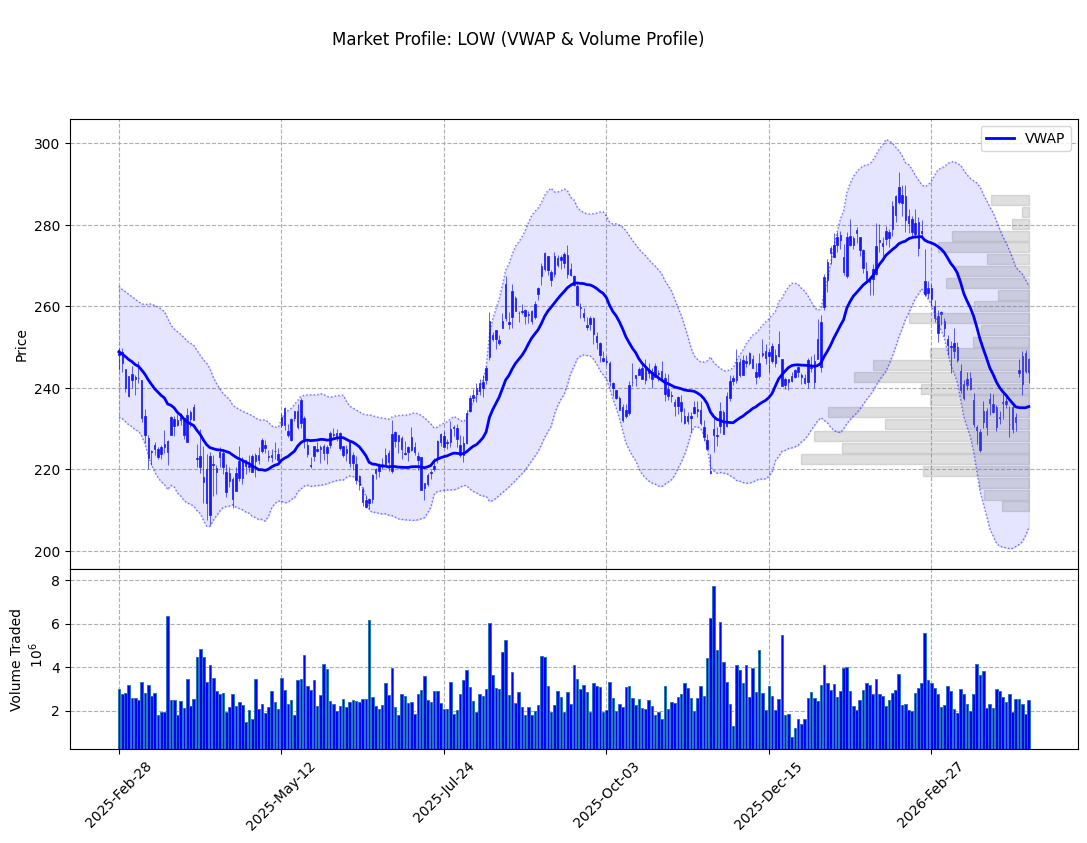

In [85]:
w = at.plot_advanced_market_profile_focus_vol('LOW', from_date="2025-01-01", to_date = '2026-04-14')

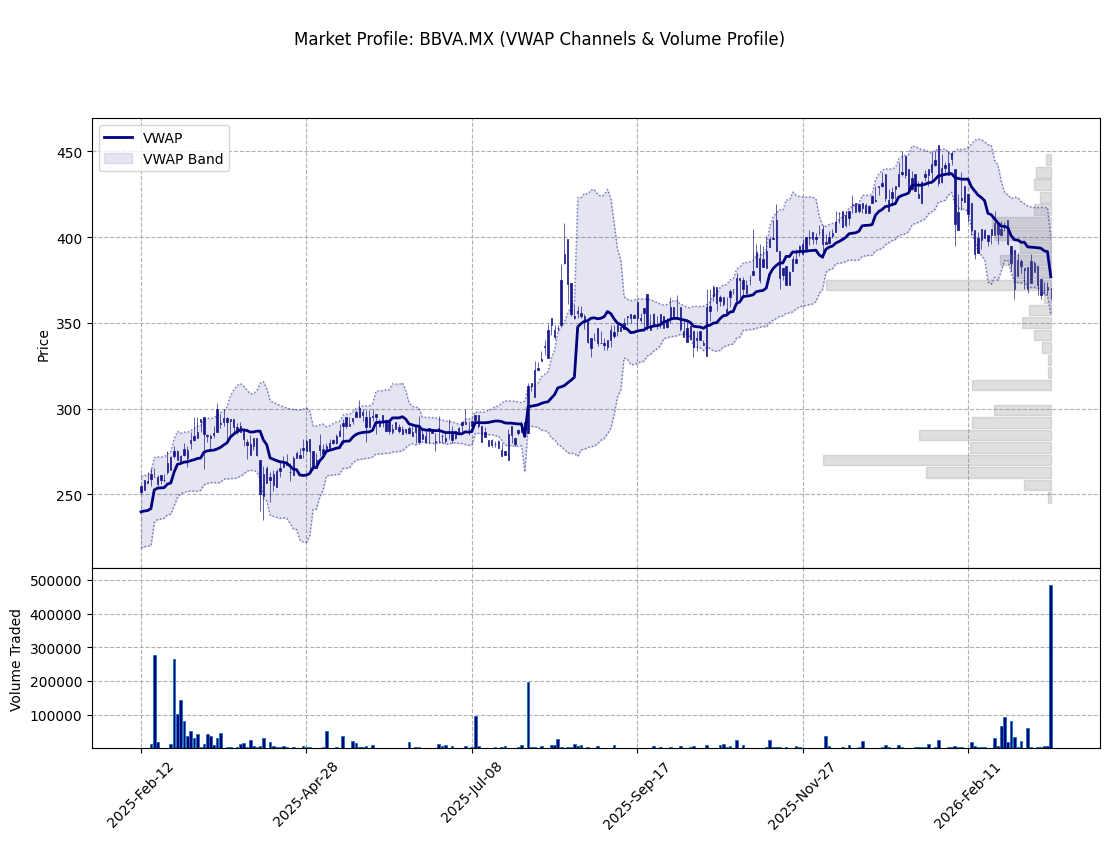

In [ ]:
# Ejemplo con Apple, usando tonalidades de azul
df_analisis = at.plot_advanced_market_profile(
    ticker="GCARSOA1.MX", 
    from_date="2025-01-01", to_date = "2026-03-20",
    vwap_window=15, 
    price_color="navy"
)

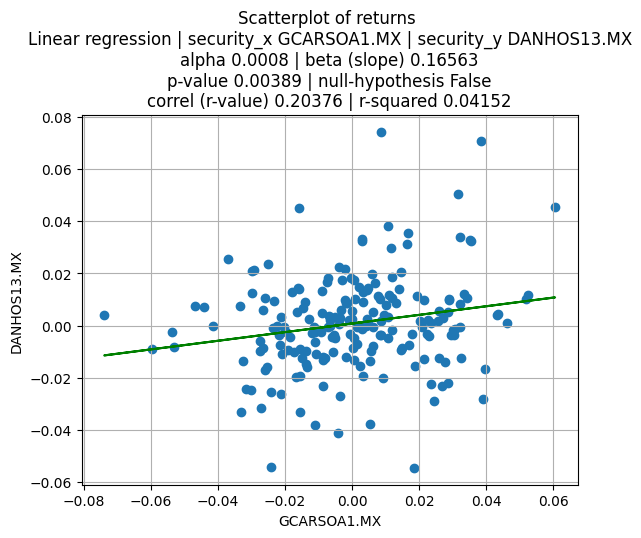

In [147]:
model = at.model('GCARSOA1.MX', 'DANHOS13.MX', model_type='macro')
model.synchronise_timeseries(from_date ='2025-08-01')
model.compute_linear_reg()
# model.plot_timeseries()
model.plot_linear_reg()

********** Resultados desde 2026-04-23 hasta 2026-05-22 **********


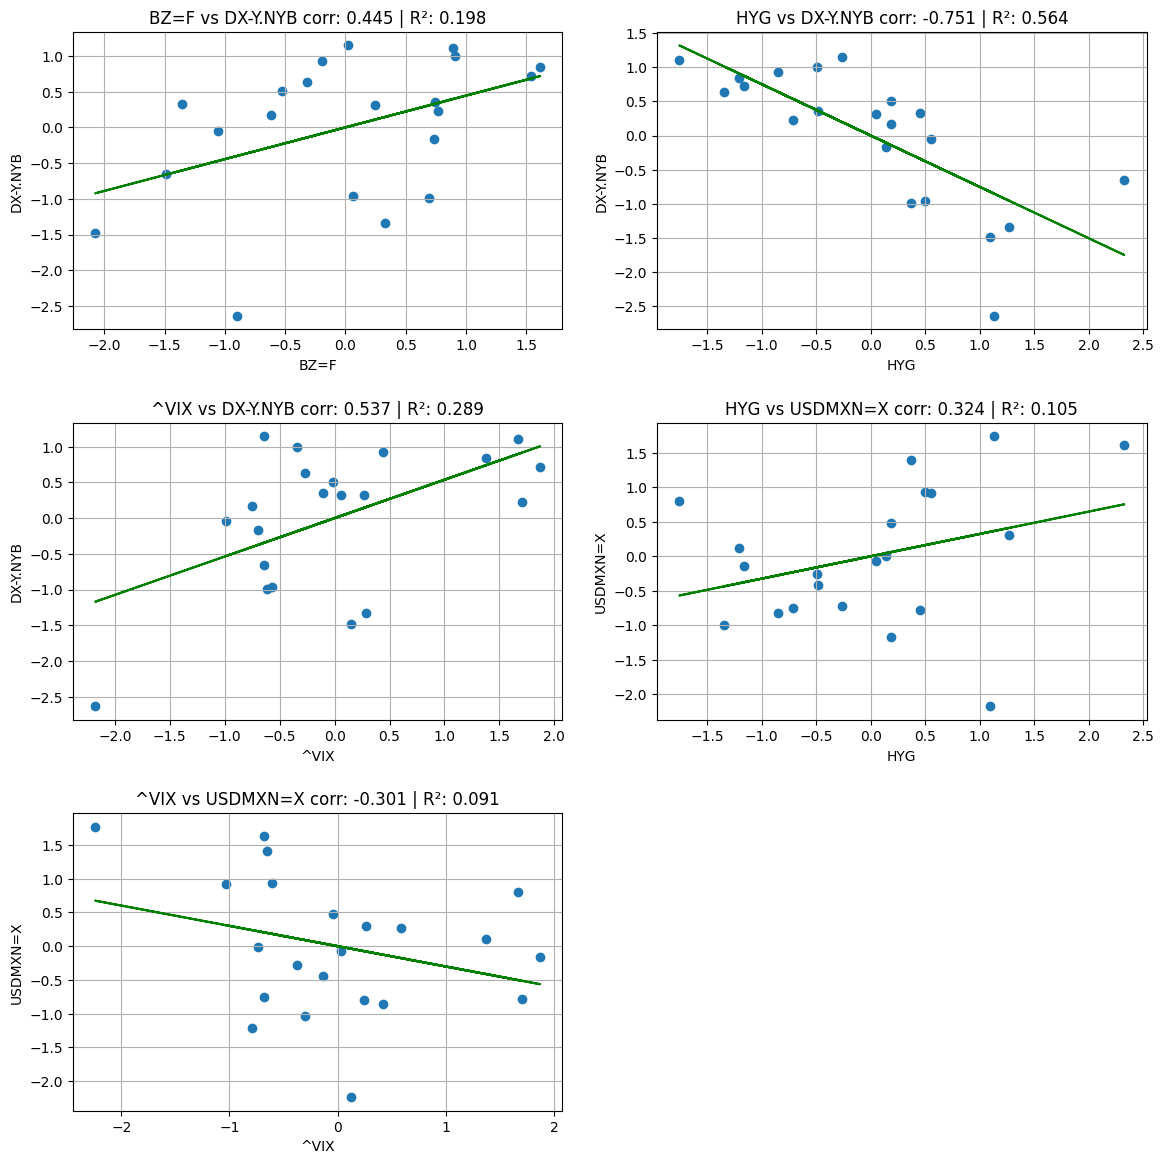

,security,benchmark,beta,correlation,r2
2,DX-Y.NYB,^VIX,0.537472,0.537472,0.288876
0,DX-Y.NYB,BZ=F,0.444889,0.444889,0.197926
4,USDMXN=X,HYG,0.323967,0.323967,0.104954
3,USDMXN=X,BZ=F,0.111212,0.111212,0.012368
5,USDMXN=X,^VIX,-0.301333,-0.301333,0.090802
1,DX-Y.NYB,HYG,-0.750775,-0.750775,0.563664


In [ ]:
benchmarks_x  = ['BZ=F', 'HYG', '^VIX']

securities_y  = ['DX-Y.NYB', 'USDMXN=X']

at.get_data(x = benchmarks_x, y = securities_y)

In [97]:
ex = at.buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2026-01-01', end_date = '2026-05-22', min_obs=60, min_corr = 0.3, freq = 'MS', order = 'score')

In [101]:
p, c = at.analizar_todo_el_df(ex)

at.imprimir_resumen_frecuencias(ex)

# 3. Desglose detallado de TODO
at.imprimir_desglose_total(p, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
at.imprimir_desglose_total(c, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: DX-Y.NYB (100.00% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: DX-Y.NYB | Bench: HYG
 > Score: 1.3249 | R2: 0.3223
 > Periodo: 2026-02-03 a 2026-04-30


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: DX-Y.NYB (Total obs: 6)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: HYG
      Frecuencia: 3 [50.00% del security]
      📉 Min R2: 0.1568 [r: -0.3959] (Score: 0.6419)
         Periodo: 2026-01-05 a 2026-03-31
      📈 Max R2: 0.3223 [r: -0.5677] (Score: 1.3249)
         Periodo: 2026-02-03 a 2026-04-30
      ····························································
   🔸 Benchmark: BZ=F
      Frecuencia: 2 [33.33% del security]
      📉 Min R2: 0

In [103]:
# 1. Generar el análisis de temporalidad para todos los pares
# Esta función te devolverá un DataFrame con los mejores periodos de cada relación
df = at.analizar_temporalidad_todos_los_pares(ex)

# 2. Imprimir los resultados de forma legible en la consola
at.imprimir_mejores_periodos(df)

# 3. (Opcional) Si quieres ver solo los top 5 con mayor score temporal de todo el año
print("\nTOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:")
print(df.nlargest(5, 'score_temporal'))


◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈
                  MEJORES VENTANAS TEMPORALES (R2 x DURACIÓN)                   
◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

📊 SECURITY: DX-Y.NYB
   ▫ Bench: HYG             | R2: 0.3223 | Días:  86 | Periodo: 2026-02-03 ➜ 2026-04-30
   ▫ Bench: BZ=F            | R2: 0.2632 | Días:  86 | Periodo: 2026-02-03 ➜ 2026-04-30
   ▫ Bench: ^VIX            | R2: 0.2307 | Días:  86 | Periodo: 2026-02-03 ➜ 2026-04-30

◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

TOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:
   security benchmark        r2  duracion_dias  score_temporal       from  \
0  DX-Y.NYB       HYG  0.322292             86       27.717112 2026-02-03   
1  DX-Y.NYB      BZ=F  0.263212             86       22.636232 2026-02-03   
2  DX-Y.NYB      ^VIX  0.230689             86       19.839254 2026-02-03   

          to  
0 2026-04-30  
1 2026-04

In [140]:
from_date = '2026-01-01'
to_date   = '2026-05-20'
tickers_yahoo = ["^MXX", "IPCCOMPMX.MX", "EWW", "EEM", "URTH","AMX"]

infra = [
    "GCARSOA1.MX",
    "ICA.MX",
    "PINFRA.MX",
    "IDEALB-1.MX",
    "CEMEXCPO.MX",
    "GCC.MX"
]
benchmarks_x  = tickers_yahoo + infra
securities_y  = ['GCARSOA1.MX']

In [141]:
at.diagnostico_covarianza_factores(benchmarks_x, from_date, to_date, umbral_corr=0.7)


1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')


Error en par ^MXX-IPCCOMPMX.MX: Yahoo Finance no devolvió datos para 'IPCCOMPMX.MX'



1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')


Error en par ^MXX-ICA.MX: Yahoo Finance no devolvió datos para 'ICA.MX'



1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly deliste

...


1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')


Error en par AMX-ICA.MX: Yahoo Finance no devolvió datos para 'ICA.MX'
Error en par GCARSOA1.MX-ICA.MX: Yahoo Finance no devolvió datos para 'ICA.MX'



1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')


Error en par ICA.MX-PINFRA.MX: Yahoo Finance no devolvió datos para 'ICA.MX'
Error en par ICA.MX-IDEALB-1.MX: Yahoo Finance no devolvió datos para 'ICA.MX'
Error en par ICA.MX-CEMEXCPO.MX: Yahoo Finance no devolvió datos para 'ICA.MX'
Error en par ICA.MX-GCC.MX: Yahoo Finance no devolvió datos para 'ICA.MX'

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
              DIAGNÓSTICO 0: CORRELACIÓN ENTRE FACTORES               
                   Periodo: 2026-01-01 a 2026-05-20                   
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ^MXX            vs EWW             | r= 0.9454 | p=0.0000 | N= 90 | ⚠️  MULTICOLINEALIDAD
  EEM             vs URTH            | r= 0.8667 | p=0.0000 | N= 94 | ⚠️  MULTICOLINEALIDAD
  EWW             vs EEM             | r= 0.7623 | p=0.0000 | N= 94 | ⚠️  MULTICOLINEALIDAD
  ^MXX            vs PINFRA.MX       | r= 0.7213 | p=0.0000 | N= 91 | ⚠️  MULTICOLINEALIDAD
  EWW             vs URTH            |

,factor_1,factor_2,correlacion,p_value,n_obs,alerta
0,^MXX,EWW,0.9454,0.0000,90,⚠️ MULTICOLINEALIDAD
17,EEM,URTH,0.8667,0.0000,94,⚠️ MULTICOLINEALIDAD
9,EWW,EEM,0.7623,0.0000,94,⚠️ MULTICOLINEALIDAD
5,^MXX,PINFRA.MX,0.7213,0.0000,91,⚠️ MULTICOLINEALIDAD
10,EWW,URTH,0.6895,0.0000,94,✅ OK
11,EWW,AMX,0.6846,0.0000,94,✅ OK
7,^MXX,CEMEXCPO.MX,0.6796,0.0000,91,✅ OK
3,^MXX,AMX,0.6609,0.0000,90,✅ OK
15,EWW,CEMEXCPO.MX,0.6398,0.0000,89,✅ OK
1,^MXX,EEM,0.6398,0.0000,90,✅ OK


In [142]:
at.diagnostico_factores_utiles(benchmarks_x, securities_y, 
                                 from_date, to_date, significance=0.05)


1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')



═══════════════════════════════════════════════════════════════════════════
               DIAGNÓSTICO 1 (KAN-ZHANG): ¿FACTORES ÚTILES?                
                     Período: 2026-01-01 → 2026-05-20                      
═══════════════════════════════════════════════════════════════════════════
Benchmark       Security       Beta   t-stat  p-value     R2    N  Veredicto
---------------------------------------------------------------------------
^MXX            GCARSOA1.MX   1.0630   6.9083   0.0000 0.3491   91  ✅ FACTOR ÚTIL
EWW             GCARSOA1.MX   0.7676   6.5371   0.0000 0.3294   89  ✅ FACTOR ÚTIL
AMX             GCARSOA1.MX   0.4969   4.4276   0.0000 0.1839   89  ✅ FACTOR ÚTIL
PINFRA.MX       GCARSOA1.MX   0.4941   4.0590   0.0001 0.1562   91  ✅ FACTOR ÚTIL
GCC.MX          GCARSOA1.MX   0.4789   4.0745   0.0001 0.1572   91  ✅ FACTOR ÚTIL
CEMEXCPO.MX     GCARSOA1.MX   0.3470   3.7135   0.0004 0.1342   91  ✅ FACTOR ÚTIL
EEM             GCARSOA1.MX   0.4015   2.8145   0.

/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:672: RuntimeWarning: invalid value encountered in sqrt
  elif t_test < t.ppf(1 - significance, self.df):
/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:676: RuntimeWarning: invalid value encountered in sqrt
  # ANOVA


(     benchmark     security      beta  t_stat  p_value        r2  n_obs  \
 0         ^MXX  GCARSOA1.MX  1.063010  6.9083   0.0000  0.349057     91   
 1          EWW  GCARSOA1.MX  0.767557  6.5371   0.0000  0.329394     89   
 4          AMX  GCARSOA1.MX  0.496883  4.4276   0.0000  0.183895     89   
 5    PINFRA.MX  GCARSOA1.MX  0.494051  4.0590   0.0001  0.156204     91   
 8       GCC.MX  GCARSOA1.MX  0.478912  4.0745   0.0001  0.157212     91   
 7  CEMEXCPO.MX  GCARSOA1.MX  0.347022  3.7135   0.0004  0.134155     91   
 2          EEM  GCARSOA1.MX  0.401455  2.8145   0.0060  0.083450     89   
 3         URTH  GCARSOA1.MX  0.712207  2.7679   0.0069  0.080934     89   
 6  IDEALB-1.MX  GCARSOA1.MX  1.038228  1.0028   0.3187  0.011172     91   
 
    es_util                         veredicto  
 0     True                     ✅ FACTOR ÚTIL  
 1     True                     ✅ FACTOR ÚTIL  
 4     True                     ✅ FACTOR ÚTIL  
 5     True                     ✅ FACTOR ÚTIL 


1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')



██████████████████████████████████████████████████████████████████████
       PIPELINE KAN-ZHANG (1999) — DETECCIÓN DE FACTORES ÚTILES       
                   Período: 2026-01-01 → 2026-05-20                   
██████████████████████████████████████████████████████████████████████

⟹  PASO 0: Multicolinealidad entre factores
Error en par ^MXX-IPCCOMPMX.MX: Yahoo Finance no devolvió datos para 'IPCCOMPMX.MX'



1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')


Error en par ^MXX-ICA.MX: Yahoo Finance no devolvió datos para 'ICA.MX'
Error en par IPCCOMPMX.MX-EWW: Yahoo Finance no devolvió datos para 'IPCCOMPMX.MX'
Error en par IPCCOMPMX.MX-EEM: Yahoo Finance no devolvió datos para 'IPCCOMPMX.MX'
Error en par IPCCOMPMX.MX-URTH: Yahoo Finance no devolvió datos para 'IPCCOMPMX.MX'



1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')


...

Error en par ICA.MX-PINFRA.MX: Yahoo Finance no devolvió datos para 'ICA.MX'
Error en par ICA.MX-IDEALB-1.MX: Yahoo Finance no devolvió datos para 'ICA.MX'
Error en par ICA.MX-CEMEXCPO.MX: Yahoo Finance no devolvió datos para 'ICA.MX'
Error en par ICA.MX-GCC.MX: Yahoo Finance no devolvió datos para 'ICA.MX'



1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')



▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
              DIAGNÓSTICO 0: CORRELACIÓN ENTRE FACTORES               
                   Periodo: 2026-01-01 a 2026-05-20                   
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ^MXX            vs EWW             | r= 0.9454 | p=0.0000 | N= 90 | ⚠️  MULTICOLINEALIDAD
  EEM             vs URTH            | r= 0.8667 | p=0.0000 | N= 94 | ⚠️  MULTICOLINEALIDAD
  EWW             vs EEM             | r= 0.7623 | p=0.0000 | N= 94 | ⚠️  MULTICOLINEALIDAD
  ^MXX            vs PINFRA.MX       | r= 0.7213 | p=0.0000 | N= 91 | ⚠️  MULTICOLINEALIDAD
  EWW             vs URTH            | r= 0.6895 | p=0.0000 | N= 94 | ✅ OK
  EWW             vs AMX             | r= 0.6846 | p=0.0000 | N= 94 | ✅ OK
  ^MXX            vs CEMEXCPO.MX     | r= 0.6796 | p=0.0000 | N= 91 | ✅ OK
  ^MXX            vs AMX             | r= 0.6609 | p=0.0000 | N= 90 | ✅ OK
  EWW             vs CEMEXCPO.MX     | r= 0.639


1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')
/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:672: RuntimeWarning: invalid value encountered in sqrt
  elif t_test < t.ppf(1 - significance, self.df):
/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:676: RuntimeWarning: invalid value encountered in sqrt
  # ANOVA



═══════════════════════════════════════════════════════════════════════════
               DIAGNÓSTICO 1 (KAN-ZHANG): ¿FACTORES ÚTILES?                
                     Período: 2026-01-01 → 2026-05-20                      
═══════════════════════════════════════════════════════════════════════════
Benchmark       Security       Beta   t-stat  p-value     R2    N  Veredicto
---------------------------------------------------------------------------
^MXX            GCARSOA1.MX   1.0630   6.9083   0.0000 0.3491   91  ✅ FACTOR ÚTIL
EWW             GCARSOA1.MX   0.7676   6.5371   0.0000 0.3294   89  ✅ FACTOR ÚTIL
AMX             GCARSOA1.MX   0.4969   4.4276   0.0000 0.1839   89  ✅ FACTOR ÚTIL
PINFRA.MX       GCARSOA1.MX   0.4941   4.0590   0.0001 0.1562   91  ✅ FACTOR ÚTIL
GCC.MX          GCARSOA1.MX   0.4789   4.0745   0.0001 0.1572   91  ✅ FACTOR ÚTIL
CEMEXCPO.MX     GCARSOA1.MX   0.3470   3.7135   0.0004 0.1342   91  ✅ FACTOR ÚTIL
EEM             GCARSOA1.MX   0.4015   2.8145   0.

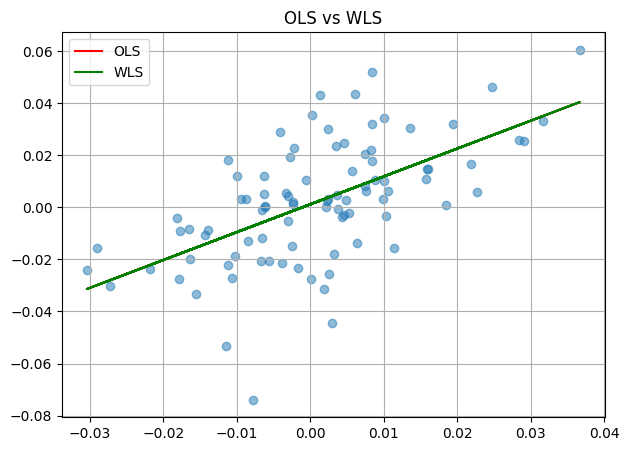

     [Diag 2] R2_OLS=0.3491 | R2_WLS=0.349 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=6.9083 | t_EIV=0.0845 | ⚠️  EIV cambia significancia — factor ruidoso



1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')


     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

  📊 IPCCOMPMX.MX → GCARSOA1.MX



1 Failed download:
['IPCCOMPMX.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-03-11)')


     [Diag 4] ERROR

  📊 EWW → GCARSOA1.MX

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 0.0015385949103763567
Beta: 0.7599233465151429

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.86603
→ NO se rechaza H0: varianza constante



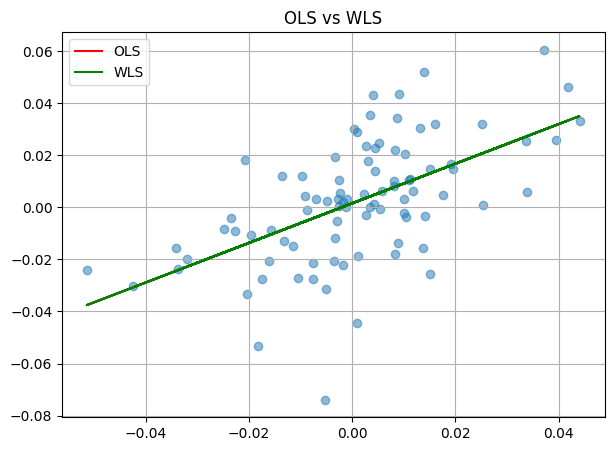

     [Diag 2] R2_OLS=0.3294 | R2_WLS=0.3294 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=6.5371 | t_EIV=0.1497 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

  📊 EEM → GCARSOA1.MX

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 0.0018526520831180678
Beta: 0.4193524680249834

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.66510
→ NO se rechaza H0: varianza constante



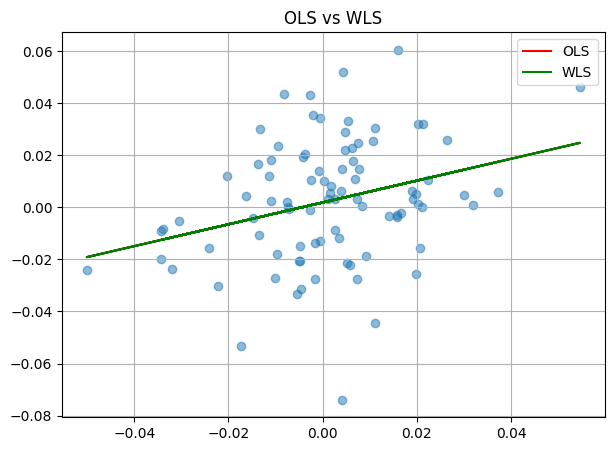

     [Diag 2] R2_OLS=0.0834 | R2_WLS=0.0833 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=2.8145 | t_EIV=0.1185 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] 🟡 SEÑAL DÉBIL (mismo signo pero no ambas sig.)

  📊 URTH → GCARSOA1.MX

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 0.0020155798587669026
Beta: 0.7639749664662346

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.65065
→ NO se rechaza H0: varianza constante



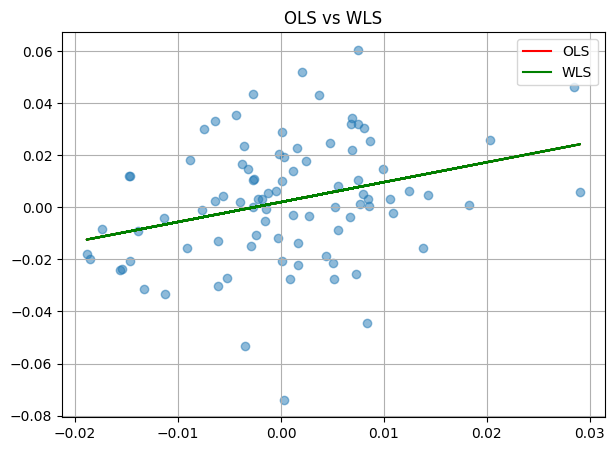

     [Diag 2] R2_OLS=0.0809 | R2_WLS=0.0805 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=2.7679 | t_EIV=0.0365 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] 🟡 SEÑAL DÉBIL (mismo signo pero no ambas sig.)

  📊 AMX → GCARSOA1.MX

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 0.0009321991673162159
Beta: 0.6026716510066664

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.19809
→ NO se rechaza H0: varianza constante



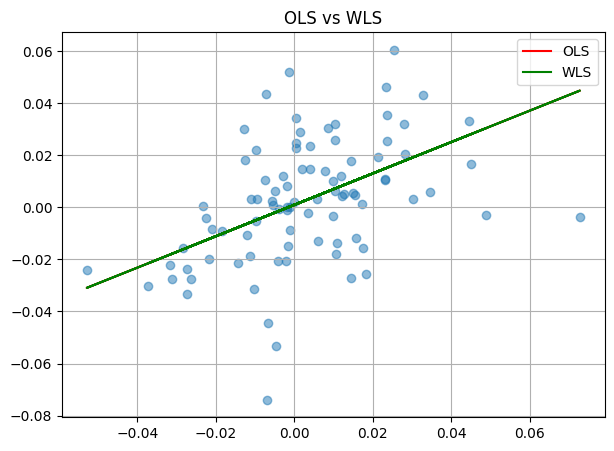

     [Diag 2] R2_OLS=0.1839 | R2_WLS=0.1753 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=4.4276 | t_EIV=0.1807 | ⚠️  EIV cambia significancia — factor ruidoso



1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')

1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-05-20)')


     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

  📊 ICA.MX → GCARSOA1.MX



1 Failed download:
['ICA.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-01-01 -> 2026-03-11)')


     [Diag 4] ERROR

  📊 PINFRA.MX → GCARSOA1.MX

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 0.0013937452784353482
Beta: 0.5402032820592064

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.94916
→ NO se rechaza H0: varianza constante



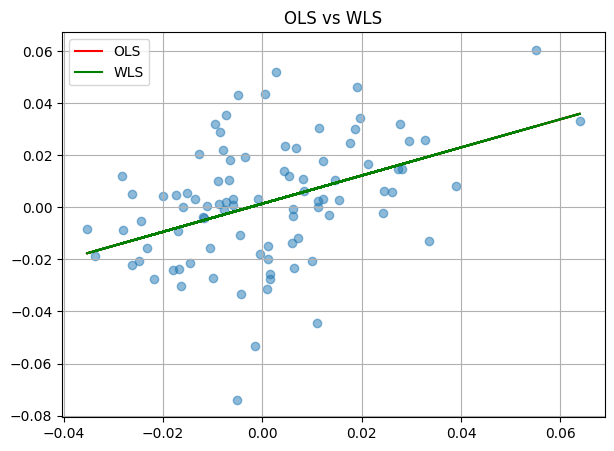

     [Diag 2] R2_OLS=0.1562 | R2_WLS=0.1548 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=4.059 | t_EIV=0.1537 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

  📊 IDEALB-1.MX → GCARSOA1.MX

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 0.002298079724784685
Beta: 1.0382284191395286

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.53075
→ NO se rechaza H0: varianza constante



/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:672: RuntimeWarning: invalid value encountered in sqrt
  elif t_test < t.ppf(1 - significance, self.df):
/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:676: RuntimeWarning: invalid value encountered in sqrt
  # ANOVA
/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:1045: RuntimeWarning: invalid value encountered in sqrt
  
/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:1053: RuntimeWarning: invalid value encountered in sqrt
  self.weights = 1 / gx


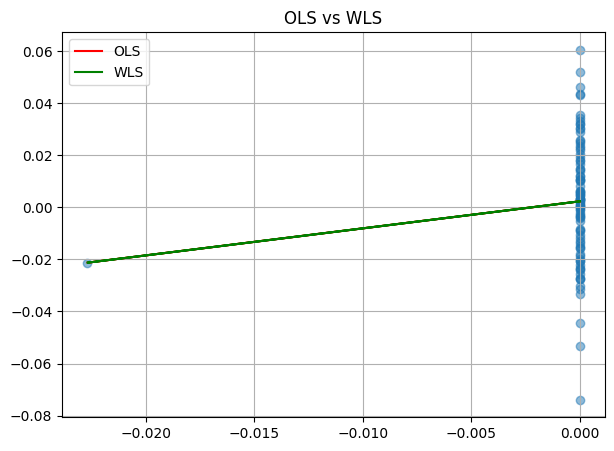

     [Diag 2] R2_OLS=0.0112 | R2_WLS=0.0112 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=1.0028 | t_EIV=0.0023 | ❌ No significativo en ambos


/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:672: RuntimeWarning: invalid value encountered in sqrt
  elif t_test < t.ppf(1 - significance, self.df):
/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:676: RuntimeWarning: invalid value encountered in sqrt
  # ANOVA


     [Diag 4] ERROR

  📊 CEMEXCPO.MX → GCARSOA1.MX

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 0.00180107038216922
Beta: 0.3541558897821209

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.70494
→ NO se rechaza H0: varianza constante



/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:672: RuntimeWarning: invalid value encountered in sqrt
  elif t_test < t.ppf(1 - significance, self.df):
/Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/automated_tools.py:676: RuntimeWarning: invalid value encountered in sqrt
  # ANOVA


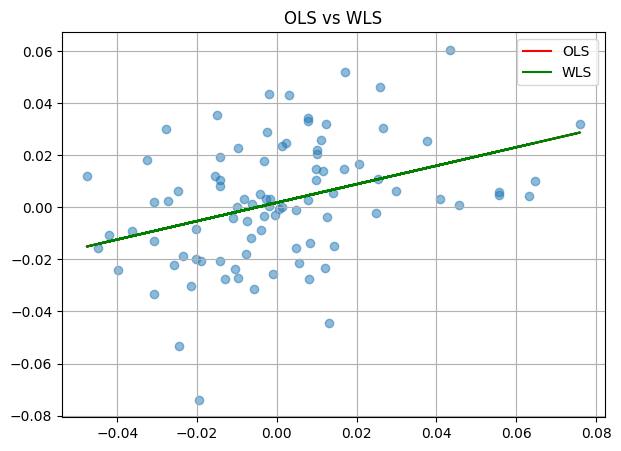

     [Diag 2] R2_OLS=0.1342 | R2_WLS=0.1341 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=3.7135 | t_EIV=0.2637 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

  📊 GCC.MX → GCARSOA1.MX

--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 0.0011069329433449993
Beta: 0.47541148938111927

--- WLS ASSUMPTIONS ---
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.42533
→ NO se rechaza H0: varianza constante



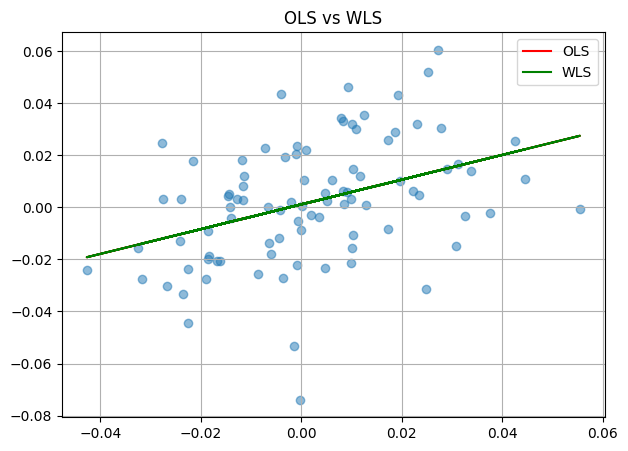

     [Diag 2] R2_OLS=0.1572 | R2_WLS=0.1572 | ✅ R2_OLS y R2_WLS consistentes
     [Diag 3] t_OLS=4.0745 | t_EIV=0.1647 | ⚠️  EIV cambia significancia — factor ruidoso
     [Diag 4] ✅ FACTOR CONSISTENTE (ambas mitades significativas, mismo signo)

══════════════════════════════════════════════════════════════════════
                   RESUMEN FINAL — RECOMENDACIONES                    
══════════════════════════════════════════════════════════════════════
  ^MXX            → GCARSOA1.MX | Puntaje: 4/6 | 🟢 USAR
  EWW             → GCARSOA1.MX | Puntaje: 4/6 | 🟢 USAR
  AMX             → GCARSOA1.MX | Puntaje: 4/6 | 🟢 USAR
  PINFRA.MX       → GCARSOA1.MX | Puntaje: 4/6 | 🟢 USAR
  CEMEXCPO.MX     → GCARSOA1.MX | Puntaje: 4/6 | 🟢 USAR
  GCC.MX          → GCARSOA1.MX | Puntaje: 4/6 | 🟢 USAR
  EEM             → GCARSOA1.MX | Puntaje: 2/6 | 🟡 CON CAUTELA
  URTH            → GCARSOA1.MX | Puntaje: 2/6 | 🟡 CON CAUTELA
  IPCCOMPMX.MX    → GCARSOA1.MX | Puntaje: 0/6 | 🔴 DESCARTAR
  ICA.MX         

(       security     benchmark  puntaje_kz  max_puntaje  recomendacion  \
 0   GCARSOA1.MX          ^MXX           4            6         🟢 USAR   
 2   GCARSOA1.MX           EWW           4            6         🟢 USAR   
 5   GCARSOA1.MX           AMX           4            6         🟢 USAR   
 7   GCARSOA1.MX     PINFRA.MX           4            6         🟢 USAR   
 9   GCARSOA1.MX   CEMEXCPO.MX           4            6         🟢 USAR   
 10  GCARSOA1.MX        GCC.MX           4            6         🟢 USAR   
 3   GCARSOA1.MX           EEM           2            6  🟡 CON CAUTELA   
 4   GCARSOA1.MX          URTH           2            6  🟡 CON CAUTELA   
 1   GCARSOA1.MX  IPCCOMPMX.MX           0            6    🔴 DESCARTAR   
 6   GCARSOA1.MX        ICA.MX           0            6    🔴 DESCARTAR   
 8   GCARSOA1.MX   IDEALB-1.MX           0            6    🔴 DESCARTAR   
 
     diag1_util  diag4_consistente  r2_ols   t_eiv  
 0         True               True  0.3491  0.0845  
 2  

In [143]:
at.pipeline_kan_zhang(benchmarks_x, securities_y, from_date, to_date)

In [ ]:
#  Una vez teniendo los factores del pipeline Kan-Zhang  

# Factores que pasaron el output anterior:
usar    = ['WALMEX.MX', 'FEMSAUBD.MX', 'DANHOS13.MX', 'FIBRAPL14.MX', 'VZ']
cautela = []
benchmarks_filtrados = usar + cautela

securities = ['GCARSOA1.MX']

# ── Betas Vasicek usando el 28-feb como quiebre ────────────────
df_vasicek = at.vasicek_pipeline(
    benchmarks_recomendados = benchmarks_filtrados,
    securities_y            = securities,
    fecha_quiebre           = '2026-02-28',
    ventana_prior_dias      = 40,    # ~2 meses de prior
    from_date_post          = '2026-02-28',
    to_date_post            = '2026-04-17',
    s2_prior_difusa         = 1.0    # prior difusa si hay pocos datos pre
)

print(df_vasicek)


██████████████████████████████████████████████████████████████████████
              PIPELINE VASICEK (1973) — BETAS BAYESIANAS              
                         Quiebre: 2026-02-28                          
                    Prior: 2026-01-19 → 2026-02-28                    
                    Post:  2026-02-28 → 2026-04-17                    
██████████████████████████████████████████████████████████████████████

────────────────────────────────────────────────────────────
  PAR: WALMEX.MX → GCARSOA1.MX
────────────────────────────────────────────────────────────

  [PRIOR — régimen pre-quiebre]

  Prior estimada de 2026-01-19 a 2026-02-28
  b' = 0.577138 | s'²_b = 0.09677402 | R² = 0.1169 | N = 28

  [MUESTRA — período de análisis]
  b_OLS = 0.816116 | s²_b = 0.12400404 | R² = 0.1610 | N = 30

  [VASICEK — combinación Bayesiana]

═════════════════════════════════════════════════════════════════
  ESTIMADOR BAYESIANO DE VASICEK (1973)
  WALMEX.MX → GCARSOA1.MX  |  N = 30 obs

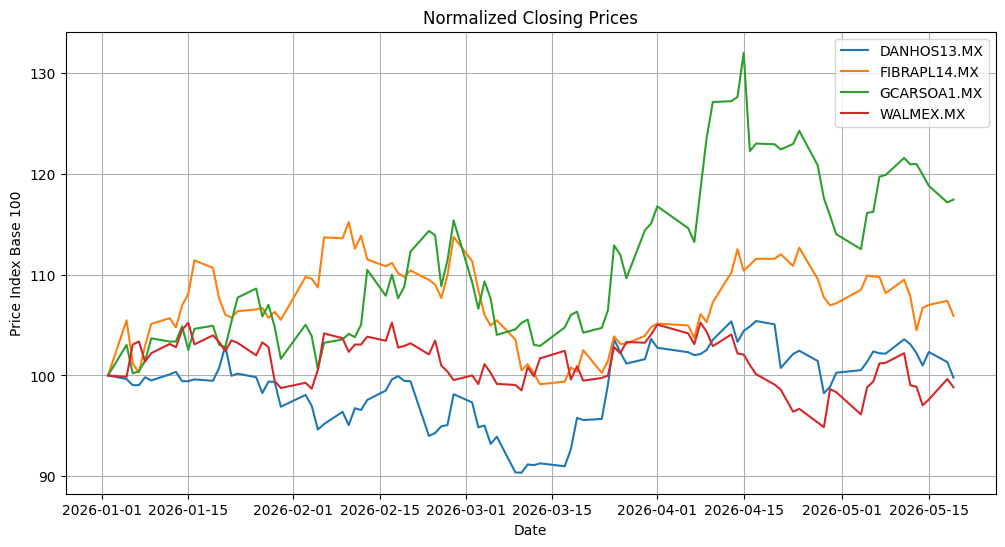

Ticker,DANHOS13.MX,FIBRAPL14.MX,GCARSOA1.MX,WALMEX.MX
Date,,,,
2026-01-02,100.000000,100.000000,100.000000,100.000000
2026-01-05,99.642865,105.466290,103.026677,99.857553
2026-01-06,99.035715,101.198641,100.205197,103.062680
2026-01-07,99.035715,100.276609,100.418945,103.365384
2026-01-08,99.821440,102.963643,101.436389,101.371083
...,...,...,...,...
2026-05-13,102.208937,104.471879,120.955884,98.878203
2026-05-14,100.989966,106.695260,119.887143,97.044160
2026-05-15,102.319755,106.989916,118.792753,97.613960


In [ ]:
at.plot_yahoo_timeseries([, 'DANHOS13.MX', 'GCARSOA1.MX', 'FIBRAPL14.MX', 'WALMEX.MX'], from_date, to_date, returns = False)

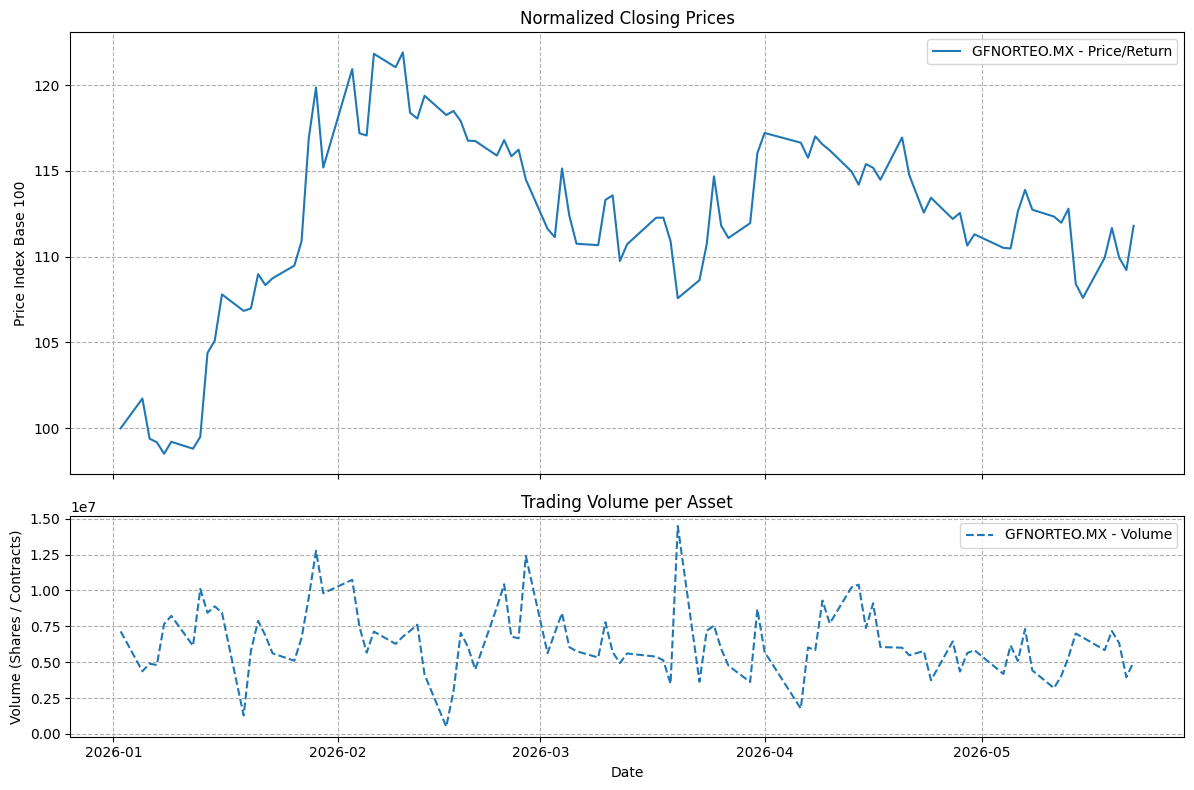

{'prices_returns': Ticker      GFNORTEO.MX
 Date                   
 2026-01-02   100.000000
 2026-01-05   101.730593
 2026-01-06    99.391959
 2026-01-07    99.181482
 2026-01-08    98.514971
 ...                 ...
 2026-05-18   109.933353
 2026-05-19   111.669789
 2026-05-20   109.945048
 2026-05-21   109.220068
 2026-05-22   111.798415
 
 [95 rows x 1 columns],
 'volume': Ticker      GFNORTEO.MX
 Date                   
 2026-01-02      7148125
 2026-01-05      4368462
 2026-01-06      4895217
 2026-01-07      4798810
 2026-01-08      7654380
 ...                 ...
 2026-05-18      5842675
 2026-05-19      7172384
 2026-05-20      6334977
 2026-05-21      3954116
 2026-05-22      5011312
 
 [95 rows x 1 columns]}

In [51]:
at.plot_yahoo_timeseries(
    ['GFNORTEO.MX'],
    from_date="2026-01-01")

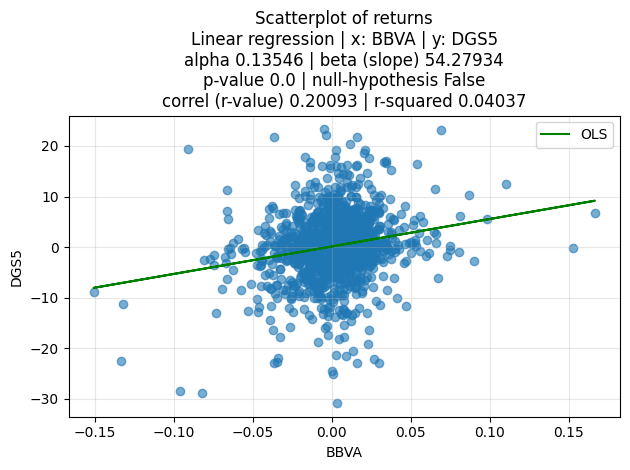

In [71]:
bbva  = at2.load_csv('BBVA', asset_type='price')
dgs5  = at2.load_csv('DGS5', asset_type='rate')

m = at2.model(bbva, dgs5,
              asset_type_x='price', asset_type_y='rate',
              name_x='BBVA', name_y='DGS5',
              model_type='macro')
m.synchronise_timeseries(from_date='2020-01-01', to_date='2024-12-31')
m.compute_linear_reg()
m.plot_linear_reg()

# AUTOMATED TOOLS VERSION 3